In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import pingouin as pg
import scipy.stats as stats
import statsmodels.api as sm
from scipy.stats import zscore
import statsmodels.formula.api as smf
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from matplotlib.lines import Line2D
import matplotlib.lines as mlines
import math
from upsetplot import plot
import seaborn as sns

## Analyze Crispr KO effects on light-dark behavior

### Read behavior data and reorganize

In [3]:
wdir = '/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Crispr/data/Behavior_test/EthoVisionRaw/'
metadata = pd.read_excel(wdir+'metadata.xlsx',index_col=0)
dates = metadata.index.str.split('-').str[0].unique()

In [5]:
def arenawise_ev(date):
    df= pd.read_excel(wdir+'ArenaWiseStatistics-'+date+'.xlsx')
    ###rename columns and rows###
    del df['Unnamed: 0']
    df.columns = df.columns.str.replace('Independent Variable Independent Variable ', '')
    if 'Plate' in df.columns:
        df['Fish_id'] = date+'-Plate'+df['Plate'].astype(str)+'-'+df['Pcolumn'].astype(str)+df['Prow']
    else:
        df['Fish_id'] = date+'-'+df['Pcolumn'].astype(str)+df['Prow']
    df.set_index('Fish_id',inplace=True)
    df.rename(columns={'Unnamed: 1':'ETrial', 'Unnamed: 2':'Arena'}, inplace=True)
    df = df.drop(['comment','Gene','Pedigree','Treatment'],axis=1)
    Parameterlist = ['Trial','Total_distance_moved', 'Mean_velocity', 'D_zone_entry',
               'D_zone_cumulative_duration', 'D_zone_latency_to_first_entry',
               'L_zone_entry', 'L_zone_cumulative_duration',
               'L_zone_latency_to_first_entry', 'Inner_zone_entry',
               'Inner_zone_cumulative_duration',
               'Inner_zone_latency_to_first_entry', 'Outer_zone_entry',
               'Outer_zone_cumulative_duration',
               'Outer_zone_latency_to_first_entry']
    start_col_no = df.columns.to_list().index('Distance moved center-point Total mm')
    df = df.loc[:,['Trial']+df.columns[start_col_no:].to_list()]
    df.columns = Parameterlist
    #df.columns=list(df.columns[:6])+ Parameterlist
    #df =df.iloc[:,2:]
    #df['Fish_id'] = date+'-'+df['Pcolumn'].astype(str)+df['Prow']
    #df.set_index('Fish_id',inplace=True)
    
    ###clean up raw data###
    df=df[(df['D_zone_cumulative_duration']!='-')|(df['L_zone_cumulative_duration']!='-')]
    
    df['adj_d_zone_duration'] = df['D_zone_cumulative_duration'].astype(float)*480/(df['D_zone_cumulative_duration'].astype(float)+df['L_zone_cumulative_duration'].astype(float))
    
    df['adj_l_zone_duration'] = df['L_zone_cumulative_duration'].astype(float)*480/(df['L_zone_cumulative_duration'].astype(float)+df['D_zone_cumulative_duration'].astype(float))
    
    df['LDCI'] = (2*df['adj_d_zone_duration']-480)/480
    
    df['adj_outer_zone_duration'] = df['Outer_zone_cumulative_duration'].astype(float)*480/(df['Outer_zone_cumulative_duration'].astype(float)+df['Inner_zone_cumulative_duration'].astype(float))
    
    df['thigmotaxis'] = (2*df['adj_outer_zone_duration']-480)/480
    
    df['LFDE']=df['D_zone_latency_to_first_entry'].replace('-', '480').astype('float32')
    df['LFLE']=df['D_zone_latency_to_first_entry'].replace('-', '480').astype('float32')
    
    df['TDEN'] = df['D_zone_entry'].astype('int32')
    df['TLEN'] = df['L_zone_entry'].astype('int32')
    
    df['Velocity']=df['Mean_velocity'].replace('-', np.nan).astype('float32')
    df['TD']=df['Total_distance_moved'].replace('-', np.nan).astype('float32')
    
    
    def AveDuration(c,f):
        if f == 0:
            return 0
        else:
            return c/f
    
    df['ADED']=df.apply(lambda x: AveDuration(x['adj_d_zone_duration'],x['D_zone_entry']), axis=1)    
    df['ALED']=df.apply(lambda x: AveDuration(x['adj_l_zone_duration'],x['L_zone_entry']), axis=1)
    df=df.loc[df.index.value_counts()==4]
    
    ###compute parameters
    df_output = df.groupby('Fish_id')[['LDCI','LFDE','TDEN','ADED','Velocity','TD']].mean()
    for i in range(1,5):
        temp = df.loc[df.Trial==i][df_output.columns[:6]]
        temp.columns = 'T'+str(i)+'_'+temp.columns
        df_output = pd.concat((df_output,temp),axis=1)
    return df_output

In [7]:
df_output_list = []
for date in dates:
    df_output_list.append(arenawise_ev(date))
df_arena = pd.concat(df_output_list)
df_arena

/var/folders/76/sy0y1dxn0vz_wwg79p6ty5cm0000gn/T/ipykernel_52151/317042310.py:48: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Velocity']=df['Mean_velocity'].replace('-', np.nan).astype('float32')
/var/folders/76/sy0y1dxn0vz_wwg79p6ty5cm0000gn/T/ipykernel_52151/317042310.py:49: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['TD']=df['Total_distance_moved'].replace('-', np.nan).astype('float32')
/var/folders/76/sy0y1dxn0vz_wwg79p6ty5cm0000gn/T/ipykernel_52151/317042310.py:48: FutureWarning: Downcasting behavior in `replace` 

,LDCI,LFDE,TDEN,ADED,Velocity,TD,T1_LDCI,T1_LFDE,T1_TDEN,T1_ADED,...,T3_TDEN,T3_ADED,T3_Velocity,T3_TD,T4_LDCI,T4_LFDE,T4_TDEN,T4_ADED,T4_Velocity,T4_TD
Fish_id,,,,,,,,,,,,,,,,,,,,,
20230317-Plate1-10A,-0.535448,101.707924,8.00,14.207605,3.332638,1620.165039,-0.397720,111.709000,9,16.060803,...,12,12.600099,3.80489,1854.030029,-0.939133,172.802994,1,14.608147,2.88314,1404.790039
20230317-Plate1-10B,-0.291572,128.042068,10.00,16.809005,3.842473,1873.972412,-0.746488,236.098007,5,12.168563,...,8,18.909074,3.63249,1771.239990,0.240012,34.633900,12,24.800236,2.75347,1341.890015
20230317-Plate1-10C,-0.298933,59.116226,10.50,15.400512,2.597640,1266.477539,-0.454497,0.000000,9,14.546758,...,10,19.461518,2.56705,1251.550049,0.156686,12.946000,14,19.828910,2.56695,1249.619995
20230317-Plate1-10D,-0.044273,62.511227,5.50,53.869831,2.154193,1048.959473,-0.399119,27.827200,9,16.023499,...,6,44.640275,2.38153,1161.420044,-0.316699,153.417007,4,40.998078,2.32228,1125.239990
20230317-Plate1-11A,-0.114029,32.406750,14.00,15.077117,3.131902,1527.252686,0.114771,12.278700,14,19.110352,...,11,12.576624,2.02996,989.151001,0.021436,30.463200,16,15.321533,2.56537,1251.329956
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20250417-9D,-0.219675,35.585274,12.00,16.028783,3.471205,1700.217529,-0.140152,12.879700,13,15.874111,...,8,19.299738,2.82631,1382.670044,-0.088527,0.000000,13,16.827185,3.04382,1491.310059
20250417-9E,-0.974975,347.616394,1.25,2.116434,3.007105,1471.327271,-0.911339,362.131989,3,7.092909,...,2,1.372827,3.18482,1558.369995,-1.000000,480.000000,0,0.000000,3.96104,1936.339966
20250417-9F,-0.311589,71.387901,13.75,11.991043,4.574510,2240.979980,-0.440721,92.326500,16,8.389185,...,10,11.856950,4.73262,2317.780029,0.251613,10.009800,15,20.025803,4.14251,2029.609985


In [8]:
def zone_process(input_dir, file):  
    df_zone = pd.read_excel(input_dir+file)
    date = file.split('/')[-1].split('.')[0].split('_')[-1]
    df_zone.columns = df_zone.columns.str.replace('Independent Variable Independent Variable ', '')
    df_zone['Fish_ID'] = df_zone.loc[:, (df_zone.columns.str.endswith('Pcolumn')|df_zone.columns.str.endswith('Prow'))].astype('str').agg(''.join, axis=1)
    if 'Plate' in df_zone.columns.str.split(' ').str[-1]:
        df_zone['Fish_ID'] = date+'-'+'Plate'+df_zone.loc[:,(df_zone.columns.str.endswith('Plate')|df_zone.columns.str.endswith('Fish_ID'))].astype('str').agg('-'.join, axis=1)
    else:
        df_zone['Fish_ID'] = date+'-'+df_zone.loc[:,(df_zone.columns.str.endswith('Plate')|df_zone.columns.str.endswith('Fish_ID'))].astype('str').agg('-'.join, axis=1)
    df_zone = df_zone.loc[:,['Unnamed: 3','Trial','Distance moved center-point Total mm','Fish_ID']]
    df_zone = df_zone.loc[df_zone['Unnamed: 3']=='In D'].iloc[:, 1:]
    df_zone.rename(columns={'Distance moved center-point Total mm':'TDDZ'}, inplace=True)
    df_zone.set_index('Fish_ID', inplace=True)
    df_zone.replace('-', 0, inplace=True)
    df_output = df_zone.groupby('Fish_ID').mean()
    for i in range(1,5):
        temp = df_zone.loc[df_zone.Trial==i]
        temp.columns = 'T'+str(i)+'_'+temp.columns
        df_output = pd.concat((df_output,temp),axis=1)
    return df_output

In [11]:
zonedata_list =[]
wdir = '/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Crispr/data/Behavior_test/EthoVisionRaw/'
for file in os.listdir(wdir):
    if file.startswith('ZoneWise'):
        zonedata_list.append(zone_process(wdir, file))

/var/folders/76/sy0y1dxn0vz_wwg79p6ty5cm0000gn/T/ipykernel_52151/867765821.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_zone.replace('-', 0, inplace=True)
/var/folders/76/sy0y1dxn0vz_wwg79p6ty5cm0000gn/T/ipykernel_52151/867765821.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_zone.replace('-', 0, inplace=True)
/var/folders/76/sy0y1dxn0vz_wwg79p6ty5cm0000gn/T/ipykernel_52151/867765821.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old 

In [12]:
df_zone = pd.concat(zonedata_list)
df_zone.index = df_zone.index.str.split('-',n=1).str[1]
df_zone = df_zone.loc[:, df_zone.columns.str.contains('TDDZ')]

In [15]:
larvae_list = list(set(df_zone.index.to_list()).intersection(set(df_arena.index.to_list())))
df_output = pd.concat([df_arena.loc[larvae_list,], df_zone.loc[larvae_list, ]],axis=1)
metadata = metadata.loc[df_output.index.intersection(metadata.index)]
metadata = metadata.loc[metadata['treatment']!='na']
df_output = pd.concat((df_output,metadata),axis=1)

traitlist = ['LDCI', 'LFDE', 'TDEN', 'TDDZ','ADED', 'Velocity', 'TD']
for i in range(1, 5):
    traitlist = traitlist+['T'+str(i)+'_'+trait for trait in ['LDCI', 'LFDE', 'TDEN', 'TDDZ', 'ADED', 'Velocity', 'TD']]
traitlist = traitlist+df_output.columns[-3:].to_list()

df_output = df_output.loc[:, traitlist]

### <span style="color:red">Save the result for publication</span>

In [ ]:
#output_dir = '/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/doc/submission_2025/Supplementary_tables/'
#fn='Table S16 dark avoidance changes in knockout larvae.xlsx'
#with pd.ExcelWriter(
        #output_dir+fn,
        #mode="a",
        #engine="openpyxl",
        #if_sheet_exists="replace",
    #) as writer:
    #df_output.to_excel(writer, sheet_name="behavior data", index=True)

### remove outliers using IQR method

In [21]:
def outliers(x):
        Q1 = x.quantile(0.25)
        Q3 = x.quantile(0.75)
        IQR = Q3 - Q1
        limit1 = Q1 - 1.5*IQR
        limit2 = Q3 + 1.5*IQR
        return x[(x>limit1)&(x<limit2)]

df_all_norm_list = []
for i in range(len(list(df_output.groupby(['treatment','Pedigree'])))):
    treatment = list(df_output.groupby(['treatment','Pedigree']))[i][0][0]
    pedigree = list(df_output.groupby(['treatment','Pedigree']))[i][0][1]
    df = list(df_output.groupby(['treatment','Pedigree']))[i][1]
    df_norm_list = []
    for trait in df_output.columns[:-3]:
        df_norm_list.append(outliers(df[trait]))
    df_norm = pd.concat(df_norm_list,axis=1)
    df_norm['treatment'] = treatment
    #print(treatment)
    df_norm['Pedigree'] = pedigree
    df_all_norm_list.append(df_norm)
df_mean_stats = pd.concat(df_all_norm_list)
df_mean_stats['week'] = df_mean_stats.index.str.split('-').str[0]

##find difference between nc and sr
diff_nc_sr = df_mean_stats.loc[(df_mean_stats.week=='20241030')&(df_mean_stats.treatment.isin(['nc','sr']))].groupby('treatment').mean(df_mean_stats.columns[:-3].to_list()).diff()

##adjust the sr for gene ksr2 since the control of ksr2 was nc not sr
df_mean_stats.loc[(df_mean_stats.week=='20230317')&(df_mean_stats.treatment=='sr'), df_mean_stats.columns[:-3].to_list()] = df_mean_stats.loc[(df_mean_stats.week=='20230317')&(df_mean_stats.treatment=='sr'), df_mean_stats.columns[:-3].to_list()].astype('float32')+diff_nc_sr.loc['sr',:].astype('float32')



In [23]:
import pickle
with open('larvae_list_crispr_ko_v1.pkl', 'wb') as file:
    pickle.dump(df_mean_stats.dropna(subset=['LDCI']).index, file)

### perform statistical analysis

In [28]:
def stats_test(df):
    def symbolize(x):
        if x>0.05:
            return 'ns'
        elif x>0.01:
            return '*'
        elif x>0.001:
            return '**'
        elif x>0.0001:
            return '*'*3

        else:
            return '*'*5
    
    com_res = []
    for j, param in enumerate(df.columns[:-2]):
        #performe two-way anova if there are multiple families
        if len(df.Pedigree.unique())>1:
            results = pg.anova(data=df, dv=param, between=['treatment','Pedigree']).round(3)
        #performe one-way anova if there is only one family
        else:
            results = pg.anova(data=df, dv=param, between='treatment').round(3)
        results['parameter'] = param
        results = results.loc[results['Source']=='treatment']
        results['mean_diff'] = df.loc[df['treatment'].str.contains('1_')][param].mean()-df.loc[df['treatment']=='2_sr'][param].mean()
        com_res.append(results)
    df_com_res = pd.concat(com_res)
    df_com_res['pval_adjust'] = pg.multicomp(df_com_res['p-unc'], method = 'fdr_bh', )[1]
    df_com_res['significance'] = df_com_res['pval_adjust'].apply(symbolize)
    
    return df_com_res.set_index('parameter')

In [30]:
dic_stats_test = {}
for week in df_mean_stats['week'].unique():
    df_input = df_mean_stats.loc[df_mean_stats['week']==week]
    for treatment in df_input['treatment'].unique():
        if treatment !='sr' and treatment !='nc':
            pedigrees = list(df_input.loc[df_input['treatment']==treatment].Pedigree.unique())
            df_comp = df_input.loc[(df_input['Pedigree'].isin(pedigrees)) &(df_input['treatment'].isin([treatment, 'sr']))].iloc[:,:-1]
            sample_size = df_comp['treatment'].value_counts()[treatment]
            df_comp['treatment'] = df_comp['treatment'].apply(lambda x: '1_'+x if x == treatment else '2_'+x)
            res = stats_test(df_comp)
            res['treatment']=treatment
            res['sample_size'] = sample_size
            key = treatment+'-'+week
            dic_stats_test.update({key:res})

### <span style="color:red">Save the result for publication</span>

In [634]:
##re-organize statistical tests
res_list=[]
treatment_list = list(dic_stats_test.keys())
res_diff_list= []
sample_size_list = []
for treatment in dic_stats_test.keys():
    res_list.append(dic_stats_test[treatment]['pval_adjust'])
    res_diff_list.append(dic_stats_test[treatment]['mean_diff'])
    sample_size_list.append(dic_stats_test[treatment].iloc[0,-1])

##for genes tested in multiple experiments, select the experiment with largest sample size    
df_sample_size = pd.DataFrame({'sample_size':sample_size_list, 'gene':[x.split('-')[0] for x in list(dic_stats_test.keys())]})
df_sample_size.index = list(dic_stats_test.keys())
df_sample_size = df_sample_size.loc[df_sample_size['sample_size']>=12]
selected_treatment = df_sample_size.sort_values(by=['gene', 'sample_size'], ascending=False).drop_duplicates(subset=['gene']).index

df_output=pd.concat(res_list, axis=1)+0.0001
df_output.columns=treatment_list
df_output = df_output[selected_treatment]
df_output.columns = df_output.columns.str.split('-').str[0]

output_dir = '/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/doc/submission_2025/Supplementary_tables/'
fn='Table S18 Statistic test of Crispr knockout larvae.xlsx'
with pd.ExcelWriter(
        output_dir+fn,
        mode="a",
        engine="openpyxl",
        if_sheet_exists="replace",
    ) as writer:
    df_output.to_excel(writer, sheet_name="statistic test", index=True)

#### <span style="color:blue">Plot Fig.4e</span>

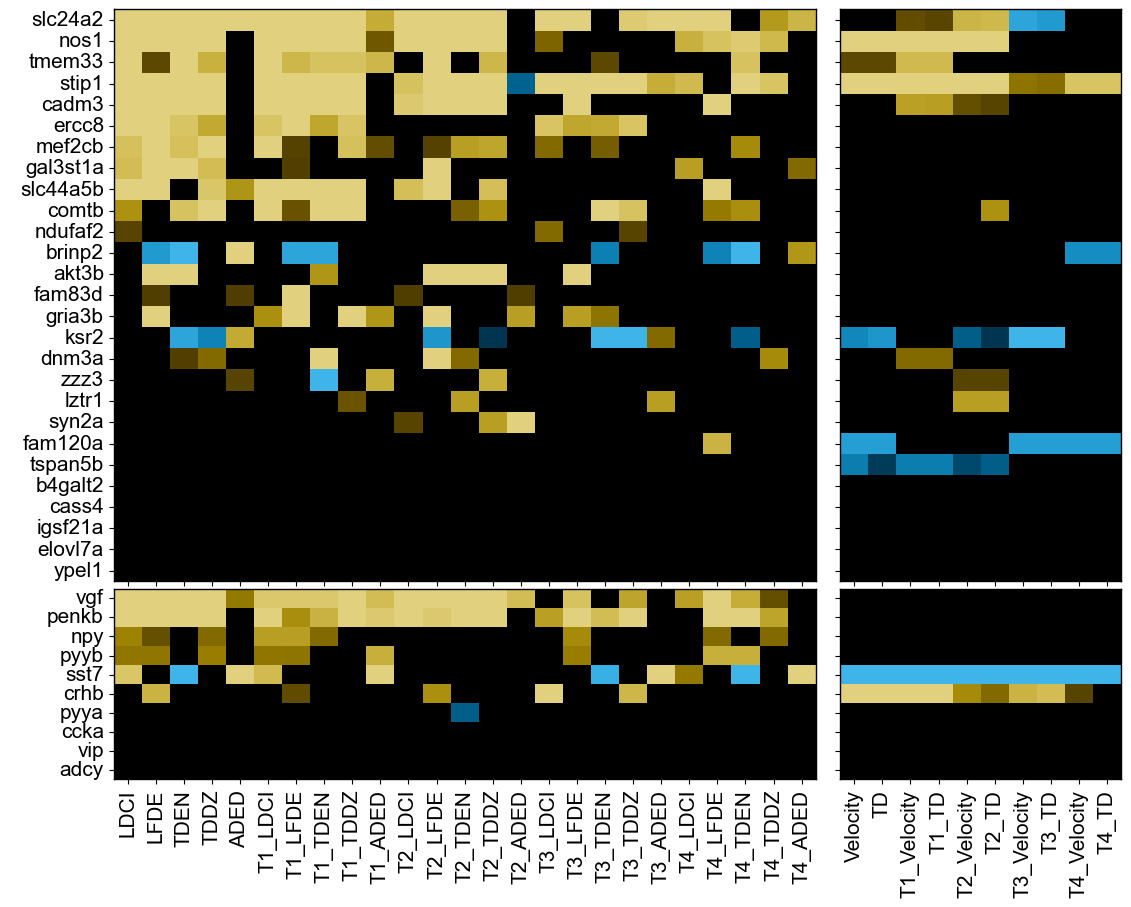

In [33]:
##re-organize statistical tests
res_list=[]
treatment_list = list(dic_stats_test.keys())
res_diff_list= []
sample_size_list = []
for treatment in dic_stats_test.keys():
    res_list.append(dic_stats_test[treatment]['pval_adjust'])
    res_diff_list.append(dic_stats_test[treatment]['mean_diff'])
    sample_size_list.append(dic_stats_test[treatment].iloc[0,-1])

##for genes tested in multiple experiments, select the experiment with largest sample size    
df_sample_size = pd.DataFrame({'sample_size':sample_size_list, 'gene':[x.split('-')[0] for x in list(dic_stats_test.keys())]})
df_sample_size.index = list(dic_stats_test.keys())
df_sample_size = df_sample_size.loc[df_sample_size['sample_size']>=12]
selected_treatment = df_sample_size.sort_values(by=['gene', 'sample_size'], ascending=False).drop_duplicates(subset=['gene']).index


df_res = pd.concat(res_list, axis=1)+0.0001
df_res.columns=treatment_list
df_res = df_res[selected_treatment]
df_res_diff = pd.concat(res_diff_list, axis=1)
df_res_diff.columns=treatment_list
df_res_diff = df_res_diff[selected_treatment]
df_res_diff.loc[df_res_diff.index.str.contains('LFDE')] = df_res_diff.loc[df_res_diff.index.str.contains('LFDE')]*(-1)
df_res = df_res.map(lambda x: 0.05 if x>0.05 else x)
df_res = df_res.mul(df_res_diff.map(lambda x: 1 if x>0 else -1))
df_plot = df_res.transpose()
orders = (abs(df_plot)<0.05).sum(axis=1).sort_values(ascending=False).index
df_plot = df_plot.loc[orders]
#df_plot = df_plot.loc[(abs(df_plot)==0.05).sum(axis=1)<df_plot.shape[1]]
npp_genes = ['sst7', 'npy', 'penkb', 'vgf', 'pyya', 'pyyb','ccka','vip','crhb', 'crhb1', 'crhb2', 'crhb3','vip','adcy']
df_plot = df_plot.loc[~df_plot.index.str.split('-').str[0].isin(npp_genes)]
df_plot_nonloco = df_plot.loc[:,~((df_plot.columns.str.contains('Velocity'))|(df_plot.columns.str[-2:]=='TD'))]
#df_plot_nonloco = df_plot_nonloco.loc[(abs(df_plot_nonloco)==0.05).sum(axis=1)<df_plot_nonloco.shape[1]]

#reorder genes based on phenotype changes
df_order = df_plot_nonloco.map(lambda x: 0 if abs(x)<0.05 else 1)
ordered_genes = df_order.sort_values(by=df_order.columns.to_list()).index
df_plot_nonloco = df_plot_nonloco.loc[ordered_genes]

#plot the heatmap of phenotypic changes for non-locomotor parameters
plt.rcdefaults()
f, ax = plt.subplots(2,2,figsize=(13,10),width_ratios=[2.5, 1], height_ratios=[3, 1],sharex=False)
plt.subplots_adjust(wspace=0.02, hspace=0.02)


temp1 = list(sns.cubehelix_palette(start=1.4, rot=0, hue=2,light=0.8, as_cmap=True, n_colors=50, reverse=True).colors)[30:]
temp2 = list(sns.cubehelix_palette(start=-0.4, rot=0,  hue=2, light=0.65,as_cmap=True,n_colors=50).colors)[30:]
colormap = temp1+temp2


g = sns.heatmap(df_plot_nonloco,cmap=sns.color_palette(palette=colormap, as_cmap=True),vmin = -0.049, vmax=0.049,linewidths=0, 
                cbar=False, mask=abs(df_plot_nonloco)==0.05,center = 0,linecolor='black',ax=ax[0][0])
g.set_yticklabels(df_plot_nonloco.index.str.split('-').str[0],fontsize=15, rotation=0)
g.set_xticklabels("")
g.set_xlabel("")
g.set_facecolor('black')
for _, spine in g.spines.items(): 
    spine.set_visible(True) 
    spine.set_linewidth(1)

#plot the heatmap of phenotypic changes for locomotor parameters
df_plot_loco = df_plot.loc[:,(df_plot.columns.str.contains('Velocity'))| (df_plot.columns.str[-2:]=='TD')]
df_plot_loco = df_plot_loco.loc[ordered_genes]
g = sns.heatmap(df_plot_loco,cmap=sns.color_palette(colormap, as_cmap=True),vmin = -0.049, vmax=0.049, linewidths=0, 
                cbar=False, mask=abs(df_plot_loco)==0.05,center = 0,linecolor='black',ax=ax[0][1])
g.set_yticklabels("")
g.set_xticklabels("")
sns.set_style("white")
g.set_facecolor("black")
g.set_xlabel("")
for _, spine in g.spines.items(): 
    spine.set_visible(True) 
    spine.set_linewidth(1)

##re-organize statistical tests
res_list=[]
treatment_list = list(dic_stats_test.keys())
res_diff_list= []
sample_size_list = []
for treatment in dic_stats_test.keys():
    res_list.append(dic_stats_test[treatment]['pval_adjust'])
    res_diff_list.append(dic_stats_test[treatment]['mean_diff'])
    sample_size_list.append(dic_stats_test[treatment].iloc[0,-1])

##for genes tested in multiple experiments, select the experiment with largest sample size    
df_sample_size = pd.DataFrame({'sample_size':sample_size_list, 'gene':[x.split('-')[0] for x in list(dic_stats_test.keys())]})
df_sample_size.index = list(dic_stats_test.keys())
df_sample_size = df_sample_size.loc[df_sample_size['sample_size']>=12]
selected_treatment = df_sample_size.sort_values(by=['gene', 'sample_size'], ascending=False).drop_duplicates(subset=['gene']).index

##change p-value for plot 
df_res = pd.concat(res_list, axis=1)+0.0001
df_res.columns=treatment_list
df_res = df_res[selected_treatment]
df_res_diff = pd.concat(res_diff_list, axis=1)
df_res_diff.columns=treatment_list
df_res_diff = df_res_diff[selected_treatment]
df_res_diff.loc[df_res_diff.index.str.contains('LFDE')] = df_res_diff.loc[df_res_diff.index.str.contains('LFDE')]*(-1)
df_res = df_res.map(lambda x: 0.05 if x>0.05 else x)
df_res = df_res.mul(df_res_diff.map(lambda x: 1 if x>0 else -1))
df_plot = df_res.transpose()
orders = (abs(df_plot)<0.05).sum(axis=1).sort_values(ascending=False).index
df_plot = df_plot.loc[orders]
#df_plot = df_plot.loc[(abs(df_plot)==0.05).sum(axis=1)<df_plot.shape[1]]
npp_genes = ['sst7', 'npy', 'penkb', 'vgf', 'pyya', 'pyyb','ccka','vip','crhb', 'crhb1', 'crhb2', 'crhb3','vip','adcy']
df_plot = df_plot.loc[df_plot.index.str.split('-').str[0].isin(npp_genes)]

##combine crhb related data
selected_list = []
for param in df_plot.loc[df_plot.index.str.contains('crhb')].columns:
    selected = (df_plot.loc[df_plot.index.str.contains('crhb')][param].abs()-0).sort_values().index[0]
    selected = df_plot.loc[df_plot.index.str.contains('crhb')].loc[selected,param]
    selected_list.append(selected)
df_plot = df_plot.loc[~df_plot.index.str.contains('crhb')]
df_plot.loc['crhb',:] = selected_list
df_plot_nonloco = df_plot.loc[:,~((df_plot.columns.str.contains('Velocity'))|(df_plot.columns.str[-2:]=='TD'))]

df_order = df_plot_nonloco.map(lambda x: 0 if abs(x)<0.05 else 1)
ordered_genes = df_order.sort_values(by=df_order.columns.to_list()).index
df_plot_nonloco = df_plot_nonloco.loc[ordered_genes]

#f, ax = plt.subplots(1,2,figsize=(20,5),width_ratios=[2, 1])
plt.subplots_adjust(wspace=0.05)

g = sns.heatmap(df_plot_nonloco,cmap=sns.color_palette(palette=colormap, as_cmap=True),vmin = -0.049, vmax=0.049,linewidths=0, 
                cbar=False, mask=abs(df_plot_nonloco)==0.05,center = 0,linecolor='black',ax=ax[1][0])
g.set_yticklabels(df_plot_nonloco.index.str.split('-').str[0],fontsize=15, rotation=0)
g.set_xticklabels(g.get_xticklabels(),fontsize=15, rotation=90)
g.set_xlabel("")
#sns.set_style("dark")
g.set_facecolor('black')
for _, spine in g.spines.items(): 
    spine.set_visible(True) 
    spine.set_linewidth(1)
    
df_plot_loco = df_plot.loc[:,(df_plot.columns.str.contains('Velocity'))| (df_plot.columns.str[-2:]=='TD')]
df_plot_loco = df_plot_loco.loc[ordered_genes]
g = sns.heatmap(df_plot_loco,cmap=sns.color_palette(colormap, as_cmap=True),vmin = -0.049, vmax=0.049, linewidths=0, 
                cbar=False, mask=abs(df_plot_loco)==0.05,center = 0,linecolor='black',ax=ax[1][1])
g.set_yticklabels("")
g.set_xticklabels(g.get_xticklabels(),fontsize=15, rotation=90)
sns.set_style("white")
g.set_facecolor('black')
g.set_xlabel("")
for _, spine in g.spines.items(): 
    spine.set_visible(True) 
    spine.set_linewidth(1)

plt.show()

### step 1. prepare phenotype data from LD pheno dataset

In [3040]:
dic = {}
for param in df_output.columns[:7]:
    li_t1t2, li_t2t3, li_t3t4,li_t1t4= 'LI_'+param+'_T1T2','LI_'+param+'_T2T3', 'LI_'+param+'_T3T4','LI_'+param+'_T1T4'
    dic.update({li_t1t2:df_output['T2_'+param]-df_output['T1_'+param], 
               li_t2t3:df_output['T3_'+param]-df_output['T2_'+param],
               li_t3t4:df_output['T4_'+param]-df_output['T3_'+param],
               li_t1t4:df_output['T4_'+param]-df_output['T1_'+param],
               'Std_'+param:df_output[['T1_'+param,'T2_'+param,'T3_'+param,'T4_'+param]].std(axis=1)})
df_output_li = pd.DataFrame(dic)
df_output_li = pd.concat([df_output_li, df_output.iloc[:, -3:]],axis=1) 

In [3042]:
def outliers(x):
        Q1 = x.quantile(0.25)
        Q3 = x.quantile(0.75)
        IQR = Q3 - Q1
        limit1 = Q1 - 1.5*IQR
        limit2 = Q3 + 1.5*IQR
        return x[(x>limit1)&(x<limit2)]

df_all_norm_list = []
for i in range(len(list(df_output_li.groupby(['treatment','Pedigree'])))):
    treatment = list(df_output_li.groupby(['treatment','Pedigree']))[i][0][0]
    pedigree = list(df_output_li.groupby(['treatment','Pedigree']))[i][0][1]
    df = list(df_output_li.groupby(['treatment','Pedigree']))[i][1]
    df_norm_list = []
    for trait in df_output_li.columns[:-3]:
        df_norm_list.append(outliers(df[trait]))
    df_norm = pd.concat(df_norm_list,axis=1)
    df_norm['treatment'] = treatment
    #print(treatment)
    df_norm['Pedigree'] = pedigree
    df_all_norm_list.append(df_norm)
df_mean_stats = pd.concat(df_all_norm_list)
df_mean_stats['week'] = df_mean_stats.index.str.split('-').str[0]
df_mean_stats

,LI_LDCI_T1T2,LI_LDCI_T2T3,LI_LDCI_T3T4,LI_LDCI_T1T4,Std_LDCI,LI_LFDE_T1T2,LI_LFDE_T2T3,LI_LFDE_T3T4,LI_LFDE_T1T4,Std_LFDE,...,LI_Velocity_T1T4,Std_Velocity,LI_TD_T1T2,LI_TD_T2T3,LI_TD_T3T4,LI_TD_T1T4,Std_TD,treatment,Pedigree,week
20250224-8A,-0.432288,0.271473,-0.090274,-0.251089,0.180384,52.519699,-52.519699,0.000000,0.000000,26.259850,...,-2.72243,1.406876,-1556.520142,603.590088,-374.500000,-1327.430054,686.170166,adcy,Z3954-02F:Z3956b-01M;Z3956b-01F:Z3954-01M,20250224
20250224-3G,0.027975,0.530127,-0.091322,0.466780,0.290412,-54.684105,-24.529200,3.570160,-75.643143,36.561241,...,-1.94137,1.651810,-400.379883,-1620.000122,NaN,-950.479980,876.420166,adcy,Z3954-02F:Z3956b-01M;Z3956b-01F:Z3954-01M,20250224
20250224-7H,0.071227,-0.252906,-0.613365,-0.795044,0.393783,-102.236000,1.501510,NaN,NaN,NaN,...,-1.51996,0.739028,-36.439941,-457.959961,-249.440063,-743.839966,361.872375,adcy,Z3954-02F:Z3956b-01M;Z3956b-01F:Z3954-01M,20250224
20250224-3C,-0.322874,0.058303,-0.676476,-0.941048,0.398223,79.329895,18.202003,-37.073105,60.458797,42.350540,...,-2.00530,0.926435,-922.149902,149.619995,-211.160034,-983.689941,455.116364,adcy,Z3954-02F:Z3956b-01M;Z3956b-01F:Z3954-01M,20250224
20250224-8C,0.057457,0.838003,0.008389,0.903849,0.503388,NaN,33.100101,-42.709801,NaN,67.545670,...,-3.09570,1.579785,-1449.500122,1120.010132,-1188.810059,-1518.300049,773.911865,adcy,Z3954-02F:Z3956b-01M;Z3956b-01F:Z3954-01M,20250224
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20241112-17E,-0.137608,0.227598,-0.701700,-0.611710,0.312274,-36.569099,-9.809646,62.094147,15.715401,29.468687,...,-2.60702,1.085716,-838.250000,218.679932,-659.010010,-1278.580078,532.079468,zzz3,Z3911-03F:Z3930-03M&Z3930-02F:Z3911-02M,20241112
20241112-20G,-0.530557,-0.139741,-0.185558,-0.855856,0.367770,34.767403,41.344097,-54.189999,21.921499,32.006760,...,-2.54615,1.049664,-506.949951,13.510010,-757.440063,-1250.880005,515.793213,zzz3,Z3911-03F:Z3930-03M&Z3930-02F:Z3911-02M,20241112
20241112-24B,0.899998,-0.018929,0.077577,0.958646,0.457812,-72.970993,-25.391800,-99.664200,NaN,NaN,...,NaN,NaN,NaN,290.289001,-76.744019,NaN,NaN,zzz3,Z3911-03F:Z3930-03M&Z3930-02F:Z3911-02M,20241112
20241112-22D,0.251087,-0.721046,0.493658,0.023699,0.302735,-80.778839,66.231239,-40.171600,-54.719200,36.980270,...,-0.80040,0.712300,459.780029,-518.239990,-333.479980,-391.939941,350.433136,zzz3,Z3911-03F:Z3930-03M&Z3930-02F:Z3911-02M,20241112


### step 2. perform stats test

In [118]:
dic_stats_test = {}
dic_stats_test_input = {}
for week in df_mean_stats['week'].unique():
    df_input = df_mean_stats.loc[df_mean_stats['week']==week]
    for treatment in df_input['treatment'].unique():
        if treatment !='sr' and treatment !='nc':
            pedigrees = list(df_input.loc[df_input['treatment']==treatment].Pedigree.unique())
            df_comp = df_input.loc[(df_input['Pedigree'].isin(pedigrees)) &(df_input['treatment'].isin([treatment, 'sr']))].iloc[:,:-1]
            sample_size = df_comp['treatment'].value_counts()[treatment]
            df_comp['treatment'] = df_comp['treatment'].apply(lambda x: '1_'+x if x == treatment else '2_'+x)
            res = stats_test(df_comp)
            res['treatment']=treatment
            res['sample_size'] = sample_size
            key = treatment+'-'+week
            dic_stats_test.update({key:res})
            dic_stats_test_input.update({key:df_comp})

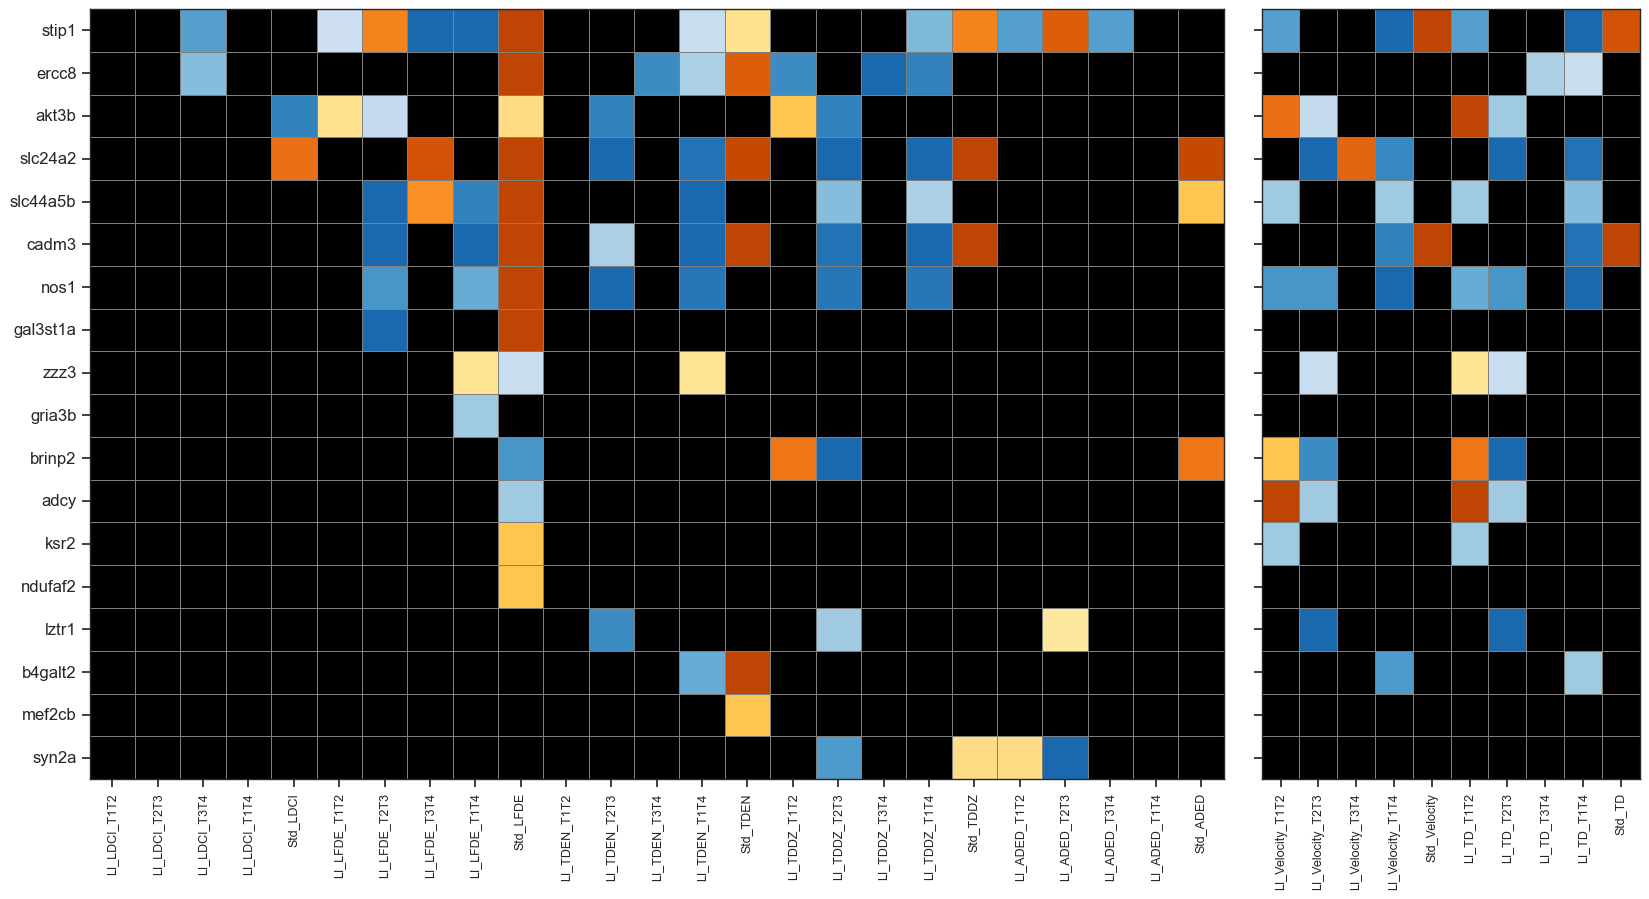

In [3046]:
##re-organize statistical tests
res_list=[]
treatment_list = list(dic_stats_test.keys())
res_diff_list= []
sample_size_list = []
for treatment in dic_stats_test.keys():
    res_list.append(dic_stats_test[treatment]['pval_adjust'])
    res_diff_list.append(dic_stats_test[treatment]['mean_diff'])
    sample_size_list.append(dic_stats_test[treatment].iloc[0,-1])

##for genes tested in multiple experiments, select the experiment with largest sample size    
df_sample_size = pd.DataFrame({'sample_size':sample_size_list, 'gene':[x.split('-')[0] for x in list(dic_stats_test.keys())]})
df_sample_size.index = list(dic_stats_test.keys())
df_sample_size = df_sample_size.loc[df_sample_size['sample_size']>12]
selected_treatment = df_sample_size.sort_values(by=['gene', 'sample_size'], ascending=False).drop_duplicates(subset=['gene']).index



df_res = pd.concat(res_list, axis=1)+0.0001
df_res.columns=treatment_list
df_res = df_res[selected_treatment]
df_res_diff = pd.concat(res_diff_list, axis=1)
df_res_diff.columns=treatment_list
df_res_diff = df_res_diff[selected_treatment]
df_res_diff.loc[df_res_diff.index.str.contains('LFDE')] = df_res_diff.loc[df_res_diff.index.str.contains('LFDE')]*(-1)
df_res = df_res.map(lambda x: 0.05 if x>0.05 else x)
df_res = df_res.mul(df_res_diff.map(lambda x: 1 if x>0 else -1))
df_plot = df_res.transpose()
orders = (abs(df_plot)<0.05).sum(axis=1).sort_values(ascending=False).index
df_plot = df_plot.loc[orders]
df_plot = df_plot.loc[(abs(df_plot)==0.05).sum(axis=1)<df_plot.shape[1]]
npp_genes = ['sst7', 'npy', 'penkb', 'vgf', 'pyya', 'pyyb','ccka','vip','crhb', 'crhb1', 'crhb2', 'crhb3','vip','adcyap1b']
df_plot = df_plot.loc[~df_plot.index.str.split('-').str[0].isin(npp_genes)]
df_plot_nonloco = df_plot.loc[:,~((df_plot.columns.str.contains('Velocity'))|(df_plot.columns.str.contains('LI_TD_'))|(df_plot.columns=='Std_TD'))]
df_plot_nonloco = df_plot_nonloco.loc[(abs(df_plot_nonloco)==0.05).sum(axis=1)<df_plot_nonloco.shape[1]]

#reorder genes based on phenotype changes
df_order = df_plot_nonloco.map(lambda x: 0 if abs(x)<0.05 else 1)
ordered_genes = df_order.sort_values(by=df_order.columns.to_list()).index
df_plot_nonloco = df_plot_nonloco.loc[ordered_genes]

#plot the heatmap of phenotypic changes for non-locomotor parameters
f, ax = plt.subplots(1,2,figsize=(20,10),width_ratios=[3, 1])
plt.subplots_adjust(wspace=0.05)

temp = sns.color_palette("YlOrBr", n_colors=50).as_hex()
temp1 = temp[10:40]
temp = sns.color_palette("Blues_r", n_colors=50).as_hex()
temp2 = temp[10:40]
colormap = temp1+temp2


g = sns.heatmap(df_plot_nonloco,cmap=sns.color_palette(palette=colormap, as_cmap=True),vmin = -0.049, vmax=0.049,linewidths=0.5, 
                cbar=False, mask=abs(df_plot_nonloco)==0.05,center = 0,linecolor='grey',ax=ax[0])
g.set_yticklabels(df_plot_nonloco.index.str.split('-').str[0],fontsize=12, rotation=0)
g.set_xticklabels(g.get_xticklabels(),fontsize=9, rotation=90)
g.set_xlabel("")
g.set_facecolor('black')
for _, spine in g.spines.items(): 
    spine.set_visible(True) 
    spine.set_linewidth(1)

#plot the heatmap of phenotypic changes for locomotor parameters
df_plot_loco = df_plot.loc[:,(df_plot.columns.str.contains('Velocity'))| (df_plot.columns.str.contains('LI_TD_'))|(df_plot.columns=='Std_TD')]
df_plot_loco = df_plot_loco.loc[ordered_genes]
g = sns.heatmap(df_plot_loco,cmap=sns.color_palette(colormap, as_cmap=True),vmin = -0.049, vmax=0.049, linewidths=0.5, 
                cbar=False, mask=abs(df_plot_loco)==0.05,center = 0,linecolor='grey',ax=ax[1])
g.set_yticklabels("")
g.set_xticklabels(g.get_xticklabels(),fontsize=9, rotation=90)
sns.set_style("white")
g.set_facecolor("black")
g.set_xlabel("")
for _, spine in g.spines.items(): 
    spine.set_visible(True) 
    spine.set_linewidth(1)
plt.show()

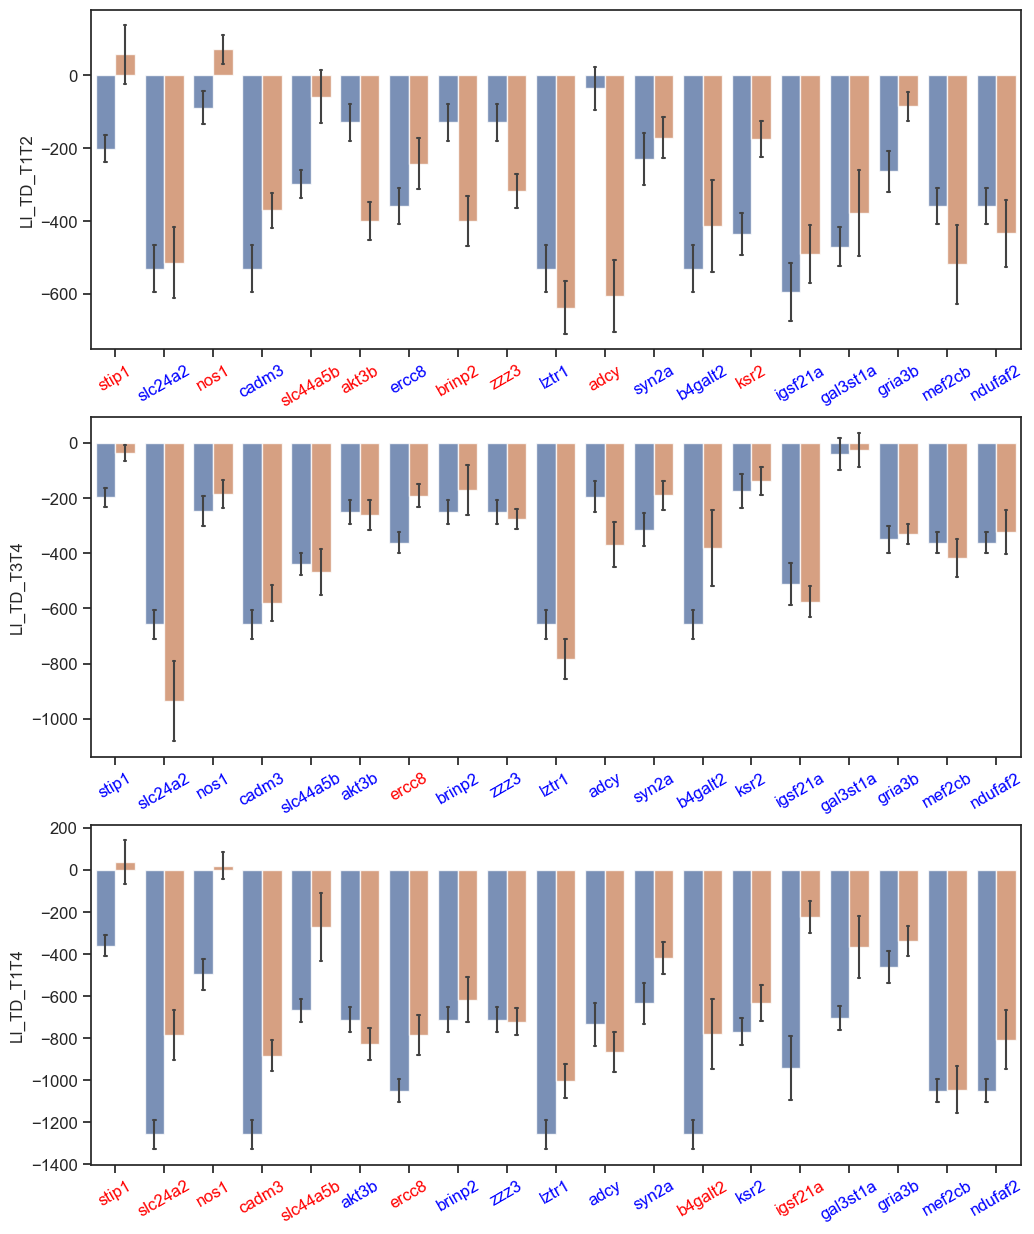

In [3049]:
custom_params = {"axes.spines.right": True, "axes.spines.top": True,
                 "xtick.labelsize":12,"ytick.labelsize":12,}
sns.set_theme(style="ticks", rc=custom_params)
selected_params = df_plot.columns[df_plot.columns.str.split('_').str[-1].isin(['T1T2', 'T3T4', 'T1T4'])].to_list()[18:]
f,ax = plt.subplots(len(selected_params),1, figsize=(12,15), sharex=False)
plt.subplots_adjust(hspace=0.2)
for i in range(len(selected_params)):
    temp_list=[]
    pval_adj_list = []
    for test in df_plot.index.to_list():
        pval_adj = dic_stats_test[test].loc[selected_params[i], 'pval_adjust']
        pval_adj_list.append(pval_adj)
        
        df_temp = dic_stats_test_input[test].copy()
        df_temp['test'] = test
        df_temp['hue'] = df_temp['treatment'].apply(lambda x: x.split('_')[0])
        df_temp = df_temp.sort_values('hue', ascending=False)
        if len(df_temp.Pedigree.unique())>1:
            s_pedigree = df_temp.Pedigree.value_counts().sort_values().index[-1]
            df_temp = df_temp.loc[df_temp.Pedigree==s_pedigree]
        #df_temp.loc[:, df_temp.columns[:-4]] = df_temp.loc[:, df_temp.columns[:-4]]-(df_temp.loc[df_temp['treatment']=='2_sr', df_temp.columns[:-4]].mean()*0.98).astype('float32')   
        temp_list.append(df_temp)

    df_bar_plot = pd.concat(temp_list).reset_index()
    g = sns.barplot(
        x="test", y=selected_params[i], hue="hue",data=df_bar_plot,
        errorbar = 'se',legend=False,err_kws={'linewidth': 1.5},capsize = 0.1,
        alpha=0.8,ax=ax[i]
    )
    g.set_xlabel('')
    g.set_xticks(np.arange(0,len(df_bar_plot.test.str.split('-').str[0].unique())))
    g.set_xticklabels(df_bar_plot.test.str.split('-').str[0].unique(),rotation=30)
    xticklabels = g.get_xticklabels()
    colors = ['red' if x < 0.05 else 'blue' for x in pval_adj_list]
    for label, color in zip(xticklabels, colors):
        label.set_color(color) 

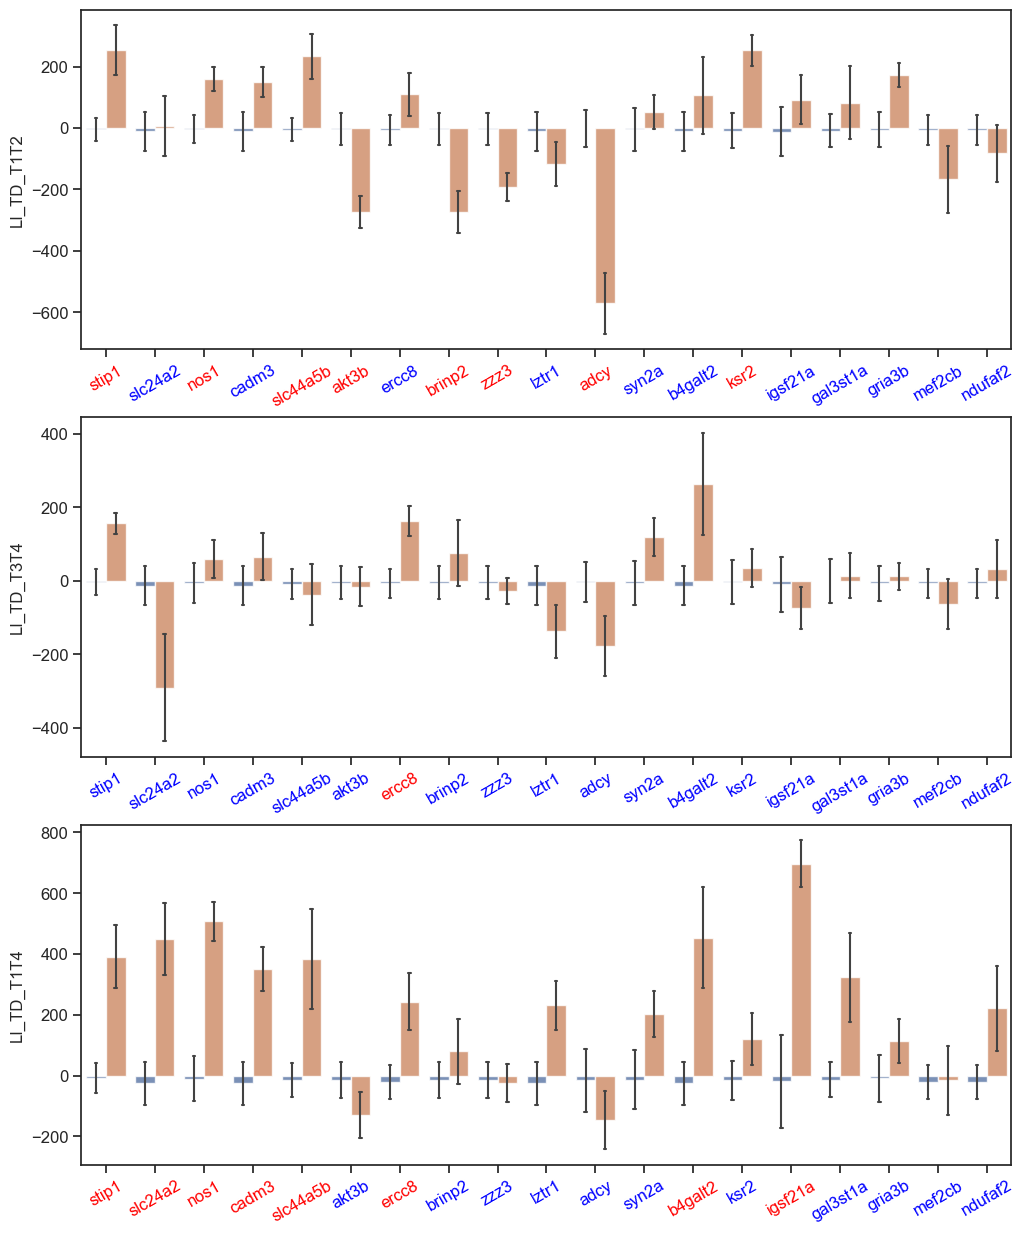

In [3038]:

custom_params = {"axes.spines.right": True, "axes.spines.top": True,
                 "xtick.labelsize":12,"ytick.labelsize":12,}
sns.set_theme(style="ticks", rc=custom_params)
selected_params = df_plot.columns[df_plot.columns.str.split('_').str[-1].isin(['T1T2', 'T3T4', 'T1T4'])].to_list()[18:]
f,ax = plt.subplots(len(selected_params),1, figsize=(12,15), sharex=False)
plt.subplots_adjust(hspace=0.2)
for i in range(len(selected_params)):
    temp_list=[]
    pval_adj_list = []
    for test in df_plot.index.to_list():
        pval_adj = dic_stats_test[test].loc[selected_params[i], 'pval_adjust']
        pval_adj_list.append(pval_adj)
        
        df_temp = dic_stats_test_input[test].copy()
        df_temp['test'] = test
        df_temp['hue'] = df_temp['treatment'].apply(lambda x: x.split('_')[0])
        df_temp = df_temp.sort_values('hue', ascending=False)
        if len(df_temp.Pedigree.unique())>1:
            s_pedigree = df_temp.Pedigree.value_counts().sort_values().index[-1]
            df_temp = df_temp.loc[df_temp.Pedigree==s_pedigree]
        df_temp.loc[:, df_temp.columns[:-4]] = df_temp.loc[:, df_temp.columns[:-4]]-(df_temp.loc[df_temp['treatment']=='2_sr', df_temp.columns[:-4]].mean()*0.98).astype('float32')   
        temp_list.append(df_temp)

    df_bar_plot = pd.concat(temp_list).reset_index()
    g = sns.barplot(
        x="test", y=selected_params[i], hue="hue",data=df_bar_plot,
        errorbar = 'se',legend=False,err_kws={'linewidth': 1.5},capsize = 0.1,
        alpha=0.8,ax=ax[i]
    )
    g.set_xlabel('')
    g.set_xticks(np.arange(0,len(df_bar_plot.test.str.split('-').str[0].unique())))
    g.set_xticklabels(df_bar_plot.test.str.split('-').str[0].unique(),rotation=30)
    xticklabels = g.get_xticklabels()
    colors = ['red' if x < 0.05 else 'blue' for x in pval_adj_list]
    for label, color in zip(xticklabels, colors):
        label.set_color(color) 

In [94]:
def bin_process(input_dir, file):

    df_bin = pd.read_excel(input_dir+file)
    date = file.split('.')[0].split('-')[-1]
    df_bin.columns = df_bin.columns.str.replace('Independent Variable Independent Variable ', '')
    df_bin['Fish_ID'] = df_bin.loc[:, (df_bin.columns.str.endswith('Pcolumn')|df_bin.columns.str.endswith('Prow'))].astype('str').agg(''.join, axis=1)
    
    if 'Plate' in df_bin.columns.str.split(' ').str[-1]:
        df_bin['Fish_ID'] = date+'-'+'Plate'+df_bin.loc[:,(df_bin.columns.str.endswith('Plate')|df_bin.columns.str.endswith('Fish_ID'))].astype('str').agg('-'.join, axis=1)
    else:
        df_bin['Fish_ID'] = date+'-'+df_bin.loc[:,(df_bin.columns.str.endswith('Plate')|df_bin.columns.str.endswith('Fish_ID'))].astype('str').agg('-'.join, axis=1)
    
    df_bin = df_bin.loc[:,['Unnamed: 3','Trial','In zone D / center-point Cumulative Duration s','In zone L / center-point Cumulative Duration s','Fish_ID']]
    
    df_bin.columns = ['timebin', 'Trial', 'Dzone_duration','Lzone_duration', 'Fish_ID']
    df_bin=df_bin[(df_bin.loc[:,'Dzone_duration']!='-')|(df_bin.loc[:,'Dzone_duration']!='-')]
    ##remove timebins with the total tracked time < 25s
    df_bin = df_bin.loc[(df_bin['Dzone_duration']+df_bin['Lzone_duration'])>=25]
    df_bin['Dzone_duration_adj'] = 30*df_bin['Dzone_duration']/(df_bin['Dzone_duration']+df_bin['Lzone_duration'])
    df_bin['LDCI'] = (2*df_bin['Dzone_duration_adj']-30)/30
    df_bin.loc[:,'timebin'] = df_bin.loc[:,'timebin'].replace({'Start-0:00:30':'0:00:00-0:00:30'})
    ##select larvae that have LDCI for each of the 64 bins 
    selected_larvae = df_bin.value_counts('Fish_ID').loc[df_bin.value_counts('Fish_ID')==64].index
    df_bin = df_bin.loc[df_bin.Fish_ID.isin(selected_larvae)]
    df_bin = df_bin.loc[:, ['timebin', 'Trial', 'Fish_ID', 'LDCI']]
    return df_bin

In [96]:
input_dir ='/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Crispr/data/Behavior_test/EthoVisionRaw/'
file = 'BinWiseStatistics-20241217.xlsx'
df_bin = bin_process(input_dir, file)

/var/folders/76/sy0y1dxn0vz_wwg79p6ty5cm0000gn/T/ipykernel_63019/2809035155.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(np.arange(1,17))
/var/folders/76/sy0y1dxn0vz_wwg79p6ty5cm0000gn/T/ipykernel_63019/2809035155.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(np.arange(1,17))


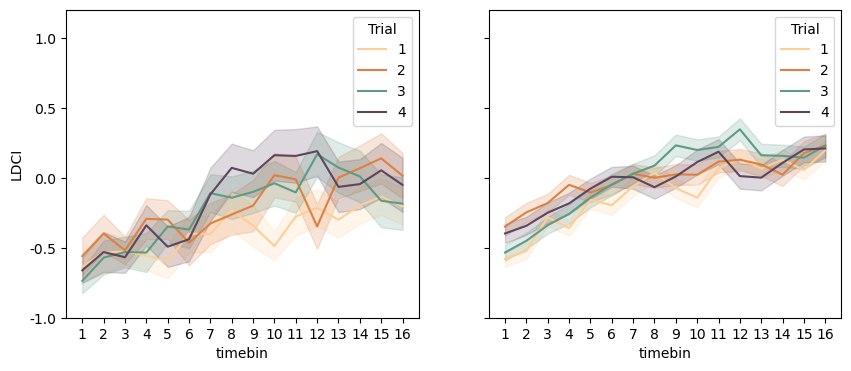

In [98]:
gene = 'mef2cb'
pedigree = 'Z3957-01F:Z3943-01M;Z3957-03F:Z3942-03M; Z3943-02F:Z3957-02M;Z3943-01F:Z3957-01M'
ko_larvae = df_mean_stats.loc[(df_mean_stats.treatment==gene)&(df_mean_stats.Pedigree==pedigree)].index
control_larvae = df_mean_stats.loc[(df_mean_stats.treatment=='sr')&(df_mean_stats.Pedigree==pedigree)].index
f, ax = plt.subplots(1,2,sharey=True, figsize=(10,4))
df_temp = df_bin.loc[df_bin.Fish_ID.isin(ko_larvae)]
g = sns.lineplot(data=df_temp, x="timebin", y="LDCI", hue='Trial',errorbar='se', 
                 palette = ["#ffce96","#de8042","#5d9b84","#5d455e"], ax=ax[0])

g.set_xticklabels(np.arange(1,17))

df_temp = df_bin.loc[df_bin.Fish_ID.isin(control_larvae)]
g = sns.lineplot(data=df_temp, x="timebin", y="LDCI", hue='Trial',errorbar='se', 
                 palette = ["#ffce96","#de8042","#5d9b84","#5d455e"], ax=ax[1])

g.set_xticklabels(np.arange(1,17))
g.set_ylim(-1,1.2)
g.set_yticks(np.arange(-1,1.5,0.5))
g.set_yticklabels( np.arange(-1,1.5,0.5))
plt.show()

In [122]:
dic_stats_test.keys()

dict_keys(['adcy-20250224', 'crhb-20250224', 'sst7-20250224', 'akt3b-20241112', 'brinp2-20241112', 'zzz3-20241112', 'b4galt2-20241121', 'cadm3-20241121', 'lztr1-20241121', 'slc24a2-20241121', 'cass4-20250327', 'tmem33-20250327', 'cass4-20250408', 'ypel1-20250408', 'ccka-20250313', 'vip-20250313', 'comtb-20250121', 'fam83d-20250121', 'slc44a5b-20250121', 'crhb1-20250417', 'crhb2-20250417', 'crhb3-20250417', 'dlgap2b-20250417', 'gal3st1a-20250417', 'dnm3a-20250213', 'npy-20250213', 'sst7-20250213', 'elovl7a-20241217', 'ercc8-20241217', 'mef2cb-20241217', 'ndufaf2-20241217', 'plk2b-20241217', 'fam120a-20250130', 'fam83d-20250130', 'slc44a5b-20250130', 'gria3b-20241212', 'igsf21a-20241212', 'gria3b-20250109', 'ksr2-20230317', 'nos1-20241030', 'nos1-20241107', 'slc24a2-20241107', 'tspan5a-20241107', 'ttyh3b-20241107', 'penkb-20250304', 'pyya-20250304', 'pyyb-20250304', 'vgf-20250304', 'syn2a-20250204', 'stip1-20220916', 'tmem33-20250401'])

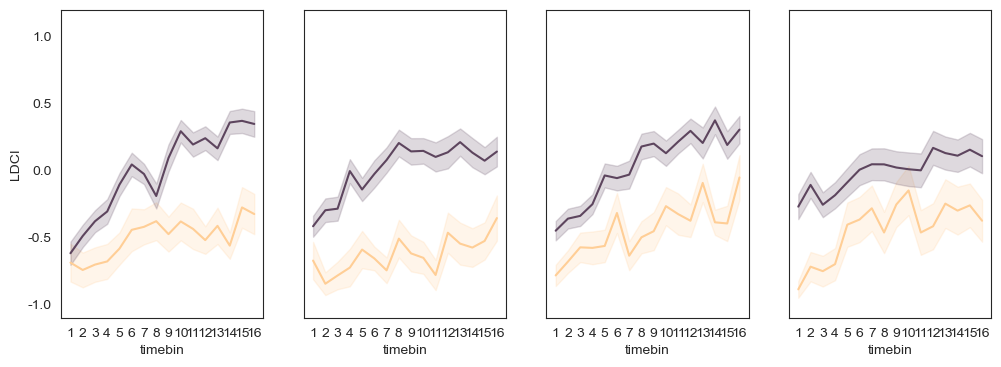

In [798]:
exp = 'slc24a2-20241121'
input_dir ='/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Crispr/data/Behavior_test/EthoVisionRaw/'
file = 'BinWiseStatistics-'+exp.split('-')[1]+'.xlsx'
df_bin = bin_process(input_dir, file)
df_temp = df_mean_stats.loc[df_mean_stats.week==exp.split('-')[1]]
pedigree = df_temp[df_temp.treatment==exp.split('-')[0]].Pedigree.unique()
ko_larvae = df_temp.loc[(df_temp.treatment==exp.split('-')[0])&(df_temp.Pedigree.isin(pedigree))].index
control_larvae = df_temp.loc[(df_temp.treatment=='sr')&(df_temp.Pedigree.isin(pedigree))].index
f, ax = plt.subplots(1,4,sharey=True, figsize=(12,4))
for i in range(1,5):
    df_temp = df_bin.loc[df_bin.Fish_ID.isin(ko_larvae)]
    g = sns.lineplot(data=df_temp.loc[df_temp.Trial==i], x="timebin", y="LDCI", errorbar='se', 
                 color = "#ffce96", ax=ax[i-1])
    df_temp = df_bin.loc[df_bin.Fish_ID.isin(control_larvae)]
    g = sns.lineplot(data=df_temp.loc[df_temp.Trial==i], x="timebin", y="LDCI",errorbar='se', 
                 color = "#5d455e", ax=ax[i-1])
    g.set_xticks(np.arange(0,16))
    g.set_xticklabels(np.arange(1,17))
    g.set_ylim(-1.1,1.2)
    g.set_yticks(np.arange(-1,1.5,0.5))
    g.set_yticklabels(np.arange(-1,1.5,0.5))
plt.show()

In [388]:
from sklearn.linear_model import LinearRegression

In [478]:

def intra_trial_curve_char(exp, trial):
    ##exp is a gene name connected with date of behavior test
    ##read raw data
    input_dir ='/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Crispr/data/Behavior_test/EthoVisionRaw/'
    file = 'BinWiseStatistics-'+exp.split('-')[1]+'.xlsx'
    ##reformat raw data
    df_bin = bin_process(input_dir, file)
    ##find a subset of the data based on the target gene and pedigree
    df_temp = df_mean_stats.loc[df_mean_stats.week==exp.split('-')[1]]
    pedigree = df_temp[df_temp.treatment==exp.split('-')[0]].Pedigree.unique()
    ko_larvae = df_temp.loc[(df_temp.treatment==exp.split('-')[0])&(df_temp.Pedigree.isin(pedigree))].index
    control_larvae = df_temp.loc[(df_temp.treatment=='sr')&(df_temp.Pedigree.isin(pedigree))].index
    
    reg_list = []
    df_temp = df_bin.loc[df_bin.Fish_ID.isin(ko_larvae)]
    df_temp = df_temp.loc[df_temp.Trial==trial]
    x = np.array(range(1,17)).reshape((-1, 1))
    y = np.array(df_temp.groupby('timebin')['LDCI'].mean())
    
    model = LinearRegression()
    model.fit(x, y)
    r_sq = model.score(x, y)
    intercept_est = model.intercept_
    slopt_est = model.coef_[0]
    
    reg_list.append([slopt_est,intercept_est, r_sq])
    
    df_temp = df_bin.loc[df_bin.Fish_ID.isin(control_larvae)]
    df_temp = df_temp.loc[df_temp.Trial==trial]
    x = np.array(range(1,17)).reshape((-1, 1))
    y = np.array(df_temp.groupby('timebin')['LDCI'].mean())
    
    model = LinearRegression()
    model.fit(x, y)
    r_sq = model.score(x, y)
    intercept_est = model.intercept_
    slopt_est = model.coef_[0]
    
    reg_list.append([slopt_est,intercept_est, r_sq])
    res = reg_list[0]+reg_list[1]+[reg_list[0][x]-reg_list[1][x] for x in range(2)]
    

    ##calculate difference between two subset of control larvae by bootstraping
    random_larvae = pd.Series(df_temp.Fish_ID.unique()).sample(round(len(control_larvae)/2)).to_list()
    df_null1 = df_temp.loc[df_temp.Fish_ID.isin(random_larvae)]
    df_null1 = df_null1.loc[df_null1.Trial==trial]
    x = np.array(range(1,17)).reshape((-1, 1))
    y = np.array(df_null1.groupby('timebin')['LDCI'].mean())
    model = LinearRegression()
    model.fit(x, y)
    r_sq = model.score(x, y)
    intercept_est = model.intercept_
    slopt_est = model.coef_[0]
    res_null = [slopt_est, intercept_est]
    
    df_null2 = df_temp.loc[~df_temp.Fish_ID.isin(df_null1.Fish_ID)]
    df_null2 = df_null2.loc[df_null2.Trial==trial]
    x = np.array(range(1,17)).reshape((-1, 1))
    y = np.array(df_null2.groupby('timebin')['LDCI'].mean())
    model = LinearRegression()
    model.fit(x, y)
    r_sq = model.score(x, y)
    intercept_est = model.intercept_
    slopt_est = model.coef_[0]
    res_null=res_null+[slopt_est,intercept_est]
    res.append(abs(res_null[0]-res_null[2]))
    res.append(abs(res_null[1]-res_null[3]))
    res = [round(x,4) for x in res]
    return res

In [508]:
intra_trial_comp = {}
for i in range(1,5):
    df_res = {}
    for exp in list(dic_stats_test.keys()):
        df_res.update({exp:intra_trial_curve_char(exp,i)})
    df_res = pd.DataFrame(df_res)
    df_res.index = ['ko_slope','ko_inte', 'ko_rsq','ctr_slope', 'ctr_inte','ctr_rsq', 'diff_slope', 'diff_inte', 'null_diff_slope','null_diff_inte']
    df_res = df_res.transpose()
    intra_trial_comp.update({i:df_res})

In [604]:
df_plot_nonloco.index

Index(['slc24a2-20241121', 'nos1-20241030', 'tmem33-20250327',
       'stip1-20220916', 'cadm3-20241121', 'ercc8-20241217', 'mef2cb-20241217',
       'gal3st1a-20250417', 'slc44a5b-20250121', 'comtb-20250121',
       'ndufaf2-20241217', 'brinp2-20241112', 'akt3b-20241112',
       'fam83d-20250130', 'gria3b-20250109', 'ksr2-20230317', 'dnm3a-20250213',
       'zzz3-20241112', 'lztr1-20241121', 'syn2a-20250204'],
      dtype='object')

In [804]:
df_temp = intra_trial_comp[1]
df_temp = df_temp.loc[abs(df_temp['diff_slope'])>=abs(df_temp['null_diff_slope']*2)]
#df_temp = df_temp.loc[df_temp.index.isin(df_plot_nonloco.index)]
df_temp

,ko_slope,ko_inte,ko_rsq,ctr_slope,ctr_inte,ctr_rsq,diff_slope,diff_inte,null_diff_slope,null_diff_inte
sst7-20250224,0.0707,-0.9462,0.7945,0.0337,-0.9184,0.7269,0.0370,-0.0278,0.0171,0.1607
zzz3-20241112,0.0283,-0.5648,0.7687,0.0553,-0.7782,0.8749,-0.0270,0.2134,0.0130,0.1885
slc24a2-20241121,0.0235,-0.7017,0.6046,0.0624,-0.5312,0.8748,-0.0389,-0.1705,0.0042,0.0182
cass4-20250327,0.0429,-0.6473,0.6322,0.0554,-0.8333,0.8349,-0.0125,0.1859,0.0032,0.1232
tmem33-20250327,0.0427,-0.9698,0.9514,0.0554,-0.8333,0.8349,-0.0127,-0.1365,0.0008,0.0066
comtb-20250121,0.0536,-1.0301,0.9249,0.0532,-0.8233,0.8838,0.0004,-0.2068,0.0001,0.0188
slc44a5b-20250121,0.0374,-1.0261,0.7647,0.0532,-0.8233,0.8838,-0.0158,-0.2028,0.0015,0.0047
sst7-20250213,0.0474,-0.9320,0.9558,0.0562,-0.8483,0.9124,-0.0088,-0.0837,0.0021,0.0803
elovl7a-20241217,0.0561,-0.7281,0.9630,0.0449,-0.4876,0.8362,0.0112,-0.2405,0.0043,0.1319
ercc8-20241217,0.0419,-0.7259,0.9127,0.0449,-0.4876,0.8362,-0.0030,-0.2384,0.0009,0.0817


In [814]:
df_temp = intra_trial_comp[3]

df_temp.sort_values('diff_inte')

,ko_slope,ko_inte,ko_rsq,ctr_slope,ctr_inte,ctr_rsq,diff_slope,diff_inte,null_diff_slope,null_diff_inte
ndufaf2-20241217,0.0613,-0.7948,0.8979,0.0497,-0.4210,0.7744,0.0116,-0.3739,0.0078,0.0734
slc24a2-20241121,0.0346,-0.7309,0.6693,0.0509,-0.3977,0.8564,-0.0163,-0.3332,0.0019,0.0619
npy-20250213,0.0491,-0.6995,0.7727,0.0314,-0.4007,0.6313,0.0177,-0.2987,0.0012,0.0226
ksr2-20230317,0.0591,-1.0859,0.8204,0.0520,-0.8092,0.8843,0.0070,-0.2767,0.0066,0.1961
crhb-20250224,0.0432,-0.9214,0.9149,0.0517,-0.6592,0.8420,-0.0085,-0.2622,0.0227,0.2638
stip1-20220916,0.0292,-0.9408,0.8106,0.0345,-0.7064,0.7765,-0.0053,-0.2344,0.0051,0.0300
ercc8-20241217,0.0403,-0.6289,0.7715,0.0497,-0.4210,0.7744,-0.0094,-0.2080,0.0135,0.0905
dnm3a-20250213,0.0540,-0.8204,0.9422,0.0435,-0.6192,0.7849,0.0105,-0.2011,0.0091,0.1542
mef2cb-20241217,0.0443,-0.6074,0.6726,0.0497,-0.4210,0.7744,-0.0054,-0.1865,0.0078,0.0102
akt3b-20241112,0.0498,-0.7233,0.8397,0.0391,-0.5830,0.8770,0.0107,-0.1403,0.0250,0.0987


# Crispr KO efficacy analysis

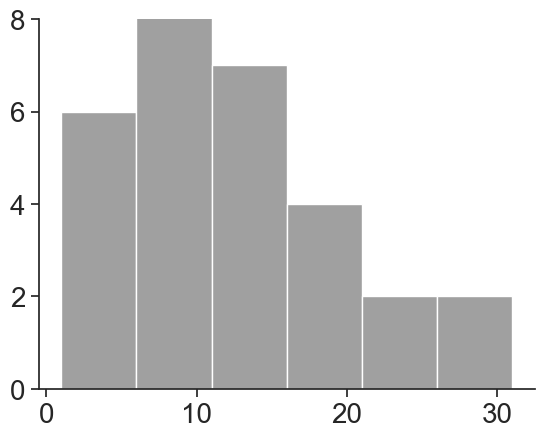

In [100]:
##re-organize statistical tests
res_list=[]
treatment_list = list(dic_stats_test.keys())
res_diff_list= []
sample_size_list = []
for treatment in dic_stats_test.keys():
    res_list.append(dic_stats_test[treatment]['pval_adjust'])
    res_diff_list.append(dic_stats_test[treatment]['mean_diff'])
    sample_size_list.append(dic_stats_test[treatment].iloc[0,-1])

##for genes tested in multiple experiments, select the experiment with largest sample size    
df_sample_size = pd.DataFrame({'sample_size':sample_size_list, 'gene':[x.split('-')[0] for x in list(dic_stats_test.keys())]})
df_sample_size.index = list(dic_stats_test.keys())
df_sample_size = df_sample_size.loc[df_sample_size['sample_size']>=12]
selected_treatment = df_sample_size.sort_values(by=['gene', 'sample_size'], ascending=False).drop_duplicates(subset=['gene']).index



df_res = pd.concat(res_list, axis=1)+0.0001
df_res.columns=treatment_list
df_res = df_res[selected_treatment]
df_res_diff = pd.concat(res_diff_list, axis=1)
df_res_diff.columns=treatment_list
df_res_diff = df_res_diff[selected_treatment]
df_res_diff.loc[df_res_diff.index.str.contains('LFDE')] = df_res_diff.loc[df_res_diff.index.str.contains('LFDE')]*(-1)
df_res = df_res.map(lambda x: 0.05 if x>0.05 else x)
df_res = df_res.mul(df_res_diff.map(lambda x: 1 if x>0 else -1))
df_plot = df_res.transpose()
orders = (abs(df_plot)<0.05).sum(axis=1).sort_values(ascending=False).index
df_plot = df_plot.loc[orders]
df_plot = df_plot.loc[(abs(df_plot)==0.05).sum(axis=1)<df_plot.shape[1]]

sns.set_theme(style="ticks", rc=custom_params)
f, ax = plt.subplots(1,1)
custom_params = {"axes.spines.right": False, "axes.spines.top": False,
                 "xtick.labelsize":20,"ytick.labelsize":20,}

g = sns.histplot(data=(df_plot.abs()<0.05).sum(axis=1), bins=6, color='grey')
g.set_ylabel("")
g.set_ylim(0,8)
ax.grid(False)

#### lethal analysis

In [96]:
wdir = '/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Crispr/data/Behavior_test/EthoVisionRaw/'
df_survival = pd.read_excel(wdir+'metadata.xlsx',index_col=None,sheet_name = "survival")
df_survival['Date'] =df_survival['Date'].astype('str')
df_survival.index = df_survival['Date']+'_'+df_survival['pedigree']
df_survival = df_survival.loc[~((df_survival.Date=='20250123')&(df_survival.treatment=='fam120a'))]

dic_res = {}
for index in df_survival.index.unique():
    sr_sr = df_survival.loc[df_survival['treatment']=='sr'].loc[index, 'survival_rate']
    for treatment in df_survival.loc[index, 'treatment'].unique():
        temp_sr = df_survival.loc[df_survival['treatment']==treatment].loc[index, 'survival_rate']
        temp_sr = round(temp_sr/sr_sr,3)
        if treatment in list(dic_res.keys()):
            dic_res[treatment].append(temp_sr)
        else:
            dic_res.update({treatment:[temp_sr]})
for treatment in list(dic_res.keys()):
    average = round(sum(dic_res[treatment])/len(dic_res[treatment]),3)
    dic_res[treatment] = average

##find lethal genes that has a survival rate less than 15% of the sr injected siblings
df_sr = pd.Series(dic_res)
lethal_genes = df_sr.loc[df_sr<0.2].index.to_list()
effect_genes = df_plot.index.str.split('-').str[0].to_list()
npp_genes = ['adcyap1b','sst7', 'npy', 'penkb', 'vgf', 'pyya', 'pyyb','ccka','vip','crhb', 'crhb1', 'crhb2', 'crhb3', 'pnocb']
temp_gene_list1 = set(effect_genes+npp_genes+lethal_genes)
no_effect_genes = set(list(dic_res.keys())).difference(temp_gene_list1)-set(['nc', 'sr'])

lethal_genes

['ttyh3b',
 'klhl20',
 'ube2l3b',
 'tmem161b',
 'edil3a',
 'plk2b',
 'prkcz',
 'kaznb',
 'mon1bb',
 'adnpa',
 'grm6b',
 'rgs6',
 'klhl29',
 'slc6a1a',
 'pnocb',
 'kif26aa',
 'zfyve1',
 'hspa9',
 'nocta',
 'dlgap2b',
 'pes']

#### <span style="color:blue">Plot Fig.4b-c</span>

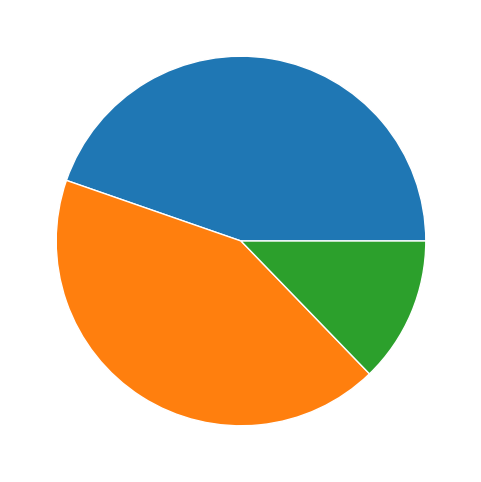

In [49]:
##pie chart for gwas genes of cirspr validation
df_plot = df_res.transpose()
orders = (abs(df_plot)<0.05).sum(axis=1).sort_values(ascending=False).index
df_plot = df_plot.loc[orders]
df_plot = df_plot.loc[(abs(df_plot)==0.05).sum(axis=1)<df_plot.shape[1]]
npp_genes = ['sst7', 'npy', 'penkb', 'vgf', 'pyya', 'pyyb','ccka','vip','crhb', 'crhb1', 'crhb2', 'crhb3','adcy']
df_plot = df_plot.loc[~df_plot.index.str.split('-').str[0].isin(npp_genes+['pnocb'])]
df_plot_nonloco = df_plot.loc[:,~((df_plot.columns.str.contains('Velocity'))|(df_plot.columns.str[-2:]=='TD'))]
df_plot_nonloco = df_plot_nonloco.loc[(abs(df_plot_nonloco)==0.05).sum(axis=1)<df_plot_nonloco.shape[1]]
df_order = df_plot_nonloco.map(lambda x: 0 if abs(x)<0.05 else 1)
ordered_genes = df_order.sort_values(by=df_order.columns.to_list()).index
df_plot_nonloco = df_plot_nonloco.loc[ordered_genes]
gwas_genes_ko_validated = set(df_plot_nonloco.index.str.split('-').str[0])
gwas_genes_lethal = set(lethal_genes).difference(set(npp_genes+['pnocb']))
gwas_genes_no_effect = set(df_res.columns.str.split('-').str[0]).difference(gwas_genes_ko_validated).difference(set(npp_genes))

data = [len(gwas_genes_ko_validated), len(gwas_genes_lethal),len(gwas_genes_no_effect)] # Sample data

sns.set_style("whitegrid") # Set style for chart
plt.figure(figsize=(6,6)) # Set figure size
plt.pie(data) # Create pie chart
plt.show() # Show chart

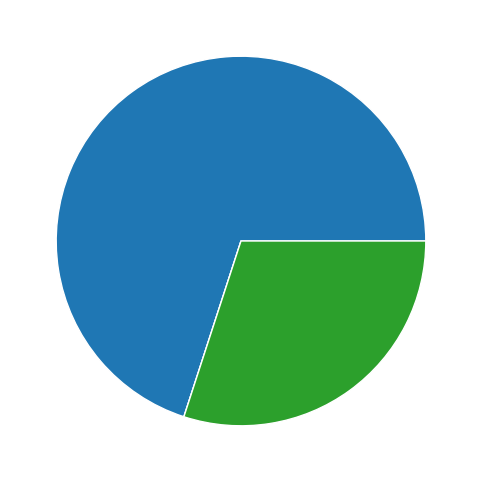

In [51]:
##pie chart for gwas genes of cirspr validation
data = [7, 0, 3] # Sample data
sns.set_style("whitegrid") # Set style for chart
plt.figure(figsize=(6,6)) # Set figure size
plt.pie(data, labels=None) # Create pie chart
plt.show() # Show chart

#### <span style="color:blue">Plot Fig.4d</span>

/var/folders/76/sy0y1dxn0vz_wwg79p6ty5cm0000gn/T/ipykernel_52151/1677601118.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_yticklabels(g.get_yticklabels(), fontsize = 15)


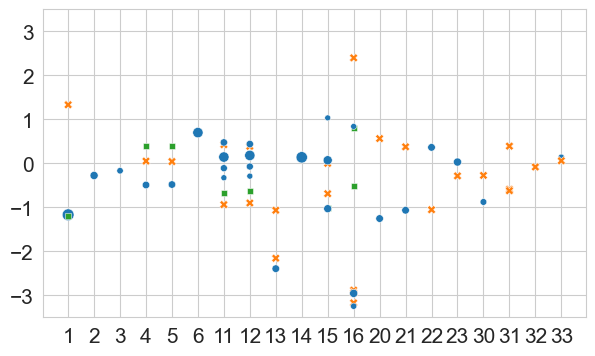

In [57]:
df_genes_in_block = pd.read_pickle('/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/zebrafish2human/processed_data/GWAS_candidate_genes_20260113.pkl')
df_temp = df_genes_in_block.loc[df_genes_in_block.Mapped_genes.isin(df_plot_nonloco.index.str.split('-').str[0]),['Mapped_genes','chr','pos',3,4,6, 'QTL_no']]
df_temp['distance'] = df_temp.apply(lambda x: x[3]-x['pos'] if x[6]=='+' else x['pos']-x[4], axis=1)

from scipy.stats import combine_pvalues
df_com_p = df_plot_nonloco.apply(lambda x: combine_pvalues(abs(x))[1],axis=1).reset_index()
df_com_p['Mapped_genes'] = df_com_p['index'].str.split('-').str[0]
df_com_p = df_com_p.iloc[:, 1:]
df_plot = pd.merge(df_temp, df_com_p, on = 'Mapped_genes')
df_plot['cat'] = 'y'

df_plot1 = df_genes_in_block.loc[df_genes_in_block.Mapped_genes.isin(gwas_genes_no_effect),['Mapped_genes','chr','pos',3,4,6, 'QTL_no']]
df_plot1['distance'] = df_plot1.apply(lambda x: x[3]-x['pos'] if x[6]=='+' else x['pos']-x[4], axis=1)
df_plot1['cat'] = 'n'

df_plot2 = df_genes_in_block.loc[df_genes_in_block.Mapped_genes.isin(gwas_genes_lethal),['Mapped_genes','chr','pos',3,4,6, 'QTL_no']]
df_plot2['distance'] = df_plot2.apply(lambda x: x[3]-x['pos'] if x[6]=='+' else x['pos']-x[4], axis=1)
df_plot2['cat'] = 'l'

df_plot = pd.concat([df_plot,df_plot1, df_plot2])
df_plot = df_plot.fillna(0.05)
df_plot = df_plot.drop_duplicates()
df_plot = df_plot.sort_values('QTL_no')
df_plot['size'] = df_plot[0].apply(lambda x: (-1)*math.log(x, 10))
df_plot.loc[df_plot['cat']=='n','size'] = df_plot.loc[df_plot['cat']=='n','size']*20
df_plot.loc[df_plot['cat']=='l','size'] = df_plot.loc[df_plot['cat']=='l','size']*20

df_plot['xpos'] = df_plot['QTL_no'].rank(method='dense')

f, ax= plt.subplots(1,1, figsize=(7,4))
g = sns.scatterplot(data=df_plot, x="xpos", y="distance",size='size', style='cat', hue='cat', ax=ax, legend=False)
g.set_ylim(-3.5*1e6, 3.5*1e6)
g.set_xticks(np.arange(1,len(df_plot['QTL_no'].unique())+1))
g.set_xticklabels(df_plot['QTL_no'].unique(), fontsize = 15)
g.set_yticklabels(g.get_yticklabels(), fontsize = 15)
g.set_ylabel('')
g.set_xlabel('')
#g.grid(False)
plt.show()

#### analyze KO efficacy

In [116]:
ice_summary = pd.read_excel("/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Crispr/data/Sanger_seq/large_scale_ko/ice_summary_v4.xlsx")
ice_summary['gene'] = ice_summary['Label'].str.split("_").str[0]
ice_summary = ice_summary.dropna(subset=['KO-Score'])

def agg_p(pval_list):
    final_p = 1
    for pval in pval_list:
        final_p = final_p*(1-pval)
    return (1-final_p)

pvals_fs_list = []
pvals_ko_list = []
for gene in ice_summary.gene.unique():
    pvals_fs = ice_summary.loc[ice_summary['gene']==gene].drop_duplicates('Label')['ICE']*0.01
    pvals_fs = agg_p(list(pvals_fs))
    pvals_fs_list.append(pvals_fs)
    pvals_ko = ice_summary.loc[ice_summary['gene']==gene].drop_duplicates('Label')['KO-Score']*0.01
    pvals_ko = agg_p(list(pvals_ko))
    pvals_ko_list.append(pvals_ko)

df_res = pd.DataFrame({"frame_shift":pvals_fs_list, "KO":pvals_ko_list})
df_res.index = ice_summary.gene.unique()
df_res = df_res.sort_values('KO', ascending=False)
df_res = df_res.reset_index()
df_res.rename(columns={'index':'gene'}, inplace=True)
df_res= df_res.dropna()

#### <span style="color:blue">Plot ED.9a,c</span>

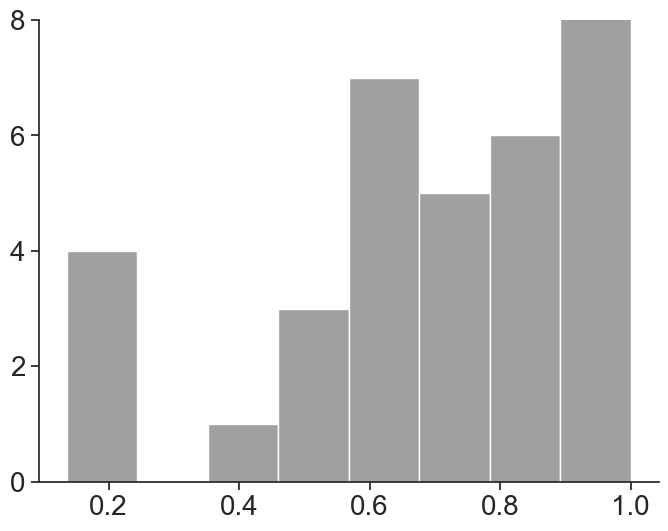

In [120]:
df_res = pd.DataFrame({"frame_shift":pvals_fs_list, "KO":pvals_ko_list})
df_res.index = ice_summary.gene.unique()
df_res = df_res.sort_values('KO', ascending=False)
df_res = df_res.reset_index()
df_res.rename(columns={'index':'gene'}, inplace=True)
df_res= df_res.dropna()

f, ax = plt.subplots(1,1, figsize=(8,6))
custom_params = {"axes.spines.right": False, "axes.spines.top": False,
                 "xtick.labelsize":20,"ytick.labelsize":20,}
sns.set_theme(style="ticks", rc=custom_params)
g = sns.histplot(data=df_res.KO, bins=8, color='grey', ax=ax)
g.set_ylabel("")
g.set_xlabel("")
g.set_ylim(0,8)
g.set_yticks(np.arange(0,10,2))
g.set_yticklabels(np.arange(0,10,2),fontsize=20)
ax.grid(False)

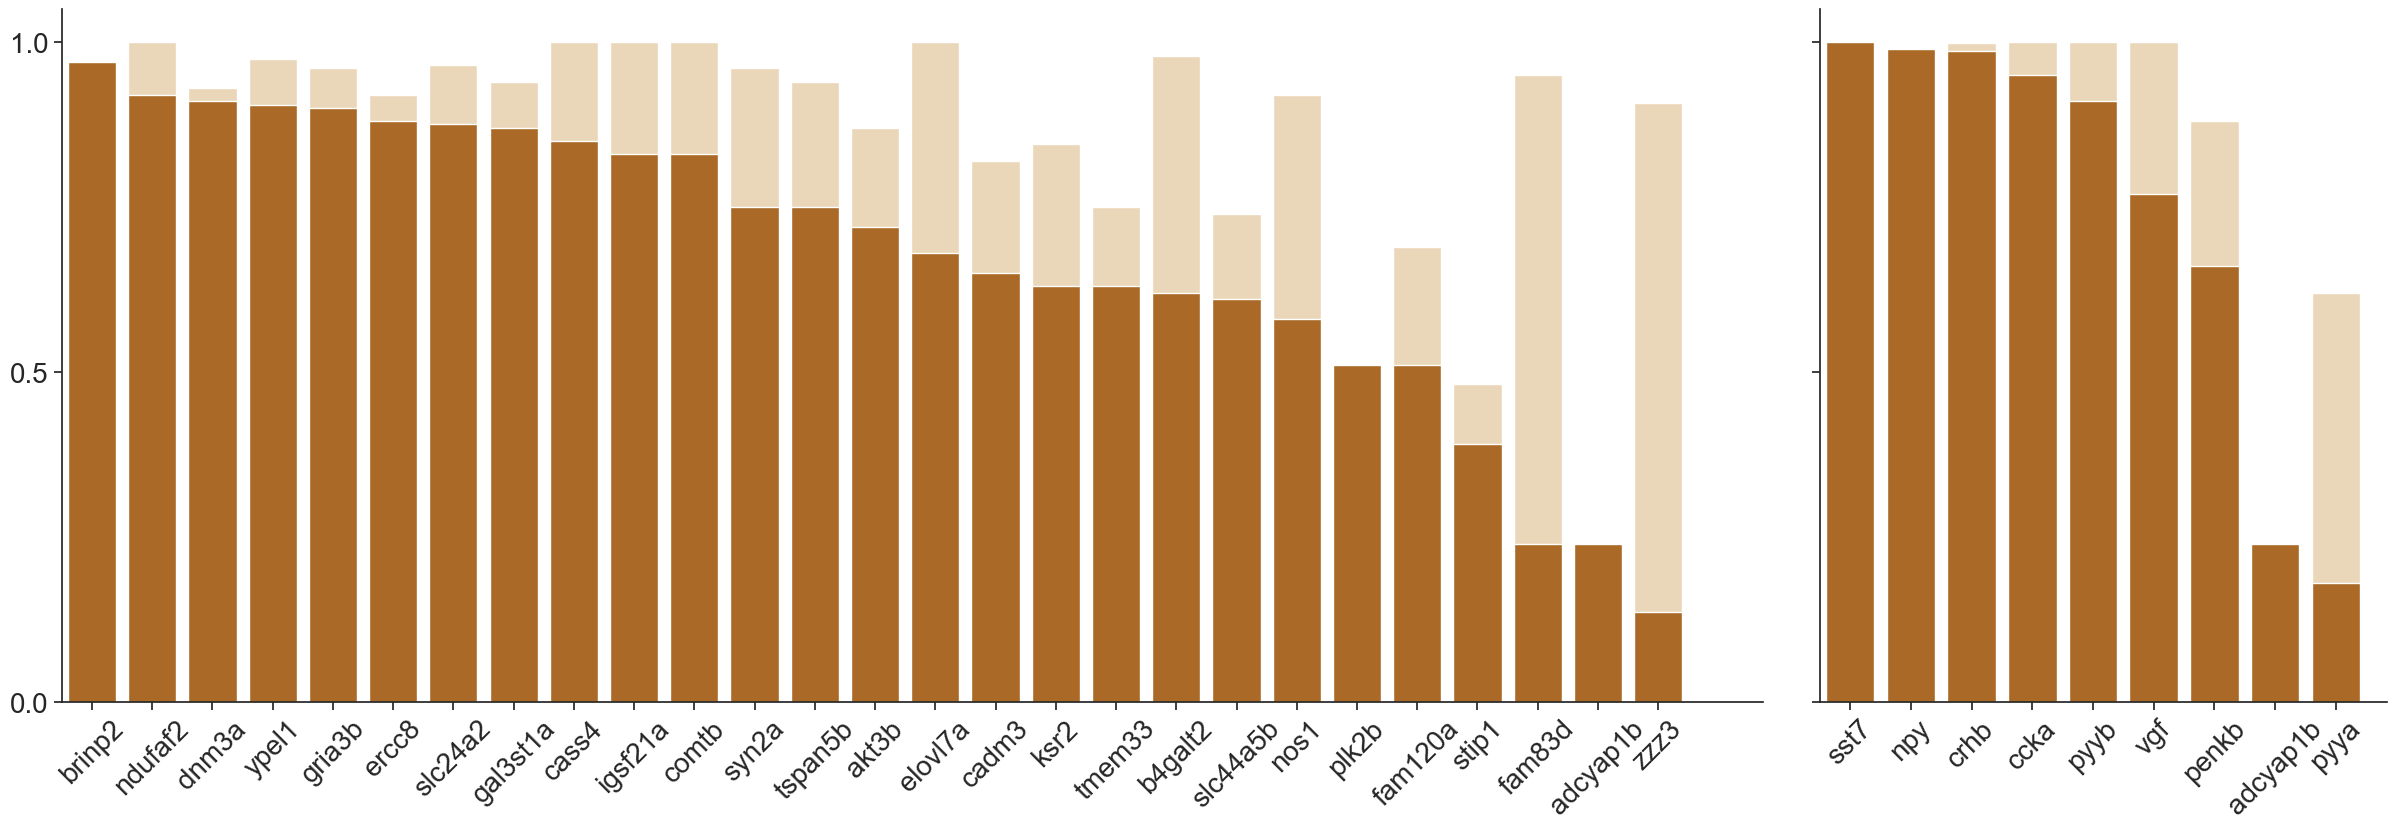

In [124]:
f,ax= plt.subplots(1,2, figsize=(30,9),width_ratios=(7.5,2.5),sharey=True)
plt.subplots_adjust(wspace=0.05)
npp_genes = ['sst7', 'npy', 'penkb', 'vgf', 'pyya', 'pyyb','ccka','vip','crhb', 'crhb1', 'crhb2', 'crhb3']

custom_params = {"axes.spines.right": False, "axes.spines.top": False,
                 "xtick.labelsize":20,"ytick.labelsize":20,}
sns.set_theme(style="ticks", rc=custom_params)

df_plot = df_res.loc[~df_res.gene.isin(npp_genes+['ttyh3b'])]
ax[0].bar(df_plot.gene, df_plot['frame_shift'], color='#EAD6B8', alpha=1, label='Value1')
ax[0].bar(df_plot.gene, df_plot['KO'], color='#AA6926', alpha=1, label='Value1')
ax[0].tick_params(axis='x', rotation=45)
ax[0].set_yticks(np.arange(0,1.5,0.5))
ax[0].set_yticklabels(np.arange(0,1.5,0.5))
ax[0].set_xlim(left=-0.5)

##plot NPGs
npp_genes = ['sst7', 'npy', 'penkb', 'vgf', 'pyya', 'pyyb','ccka','vip','crhb', 'crhb1', 'crhb2', 'crhb3','adcyap1b']
df_plot = df_res.loc[df_res.gene.isin(npp_genes)]
ax[1].bar(df_plot.gene, df_plot['frame_shift'], color='#EAD6B8', alpha=1, label='Value1')
ax[1].bar(df_plot.gene, df_plot['KO'], color='#AA6926', alpha=1, label='Value1')
ax[1].tick_params(axis='x', rotation=45)
#ax.set_xticklabels(ax.get_xticklabels(), size=12)
ax[1].set_xlim(left=-0.5)

plt.show()

### <span style="color:red">Save the result for publication</span>

In [292]:
output_dir = '/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/doc/submission_2025/Supplementary_tables/'
fn='Table S15 Crispr gRNA design.xlsx'
with pd.ExcelWriter(
        output_dir+fn,
        mode="a",
        engine="openpyxl",
        if_sheet_exists="replace",
    ) as writer:
    df_res.iloc[:, [0,2]].to_excel(writer, sheet_name="KO efficacy", index=False)

#### <span style="color:blue">Plot ED. 9d</span>

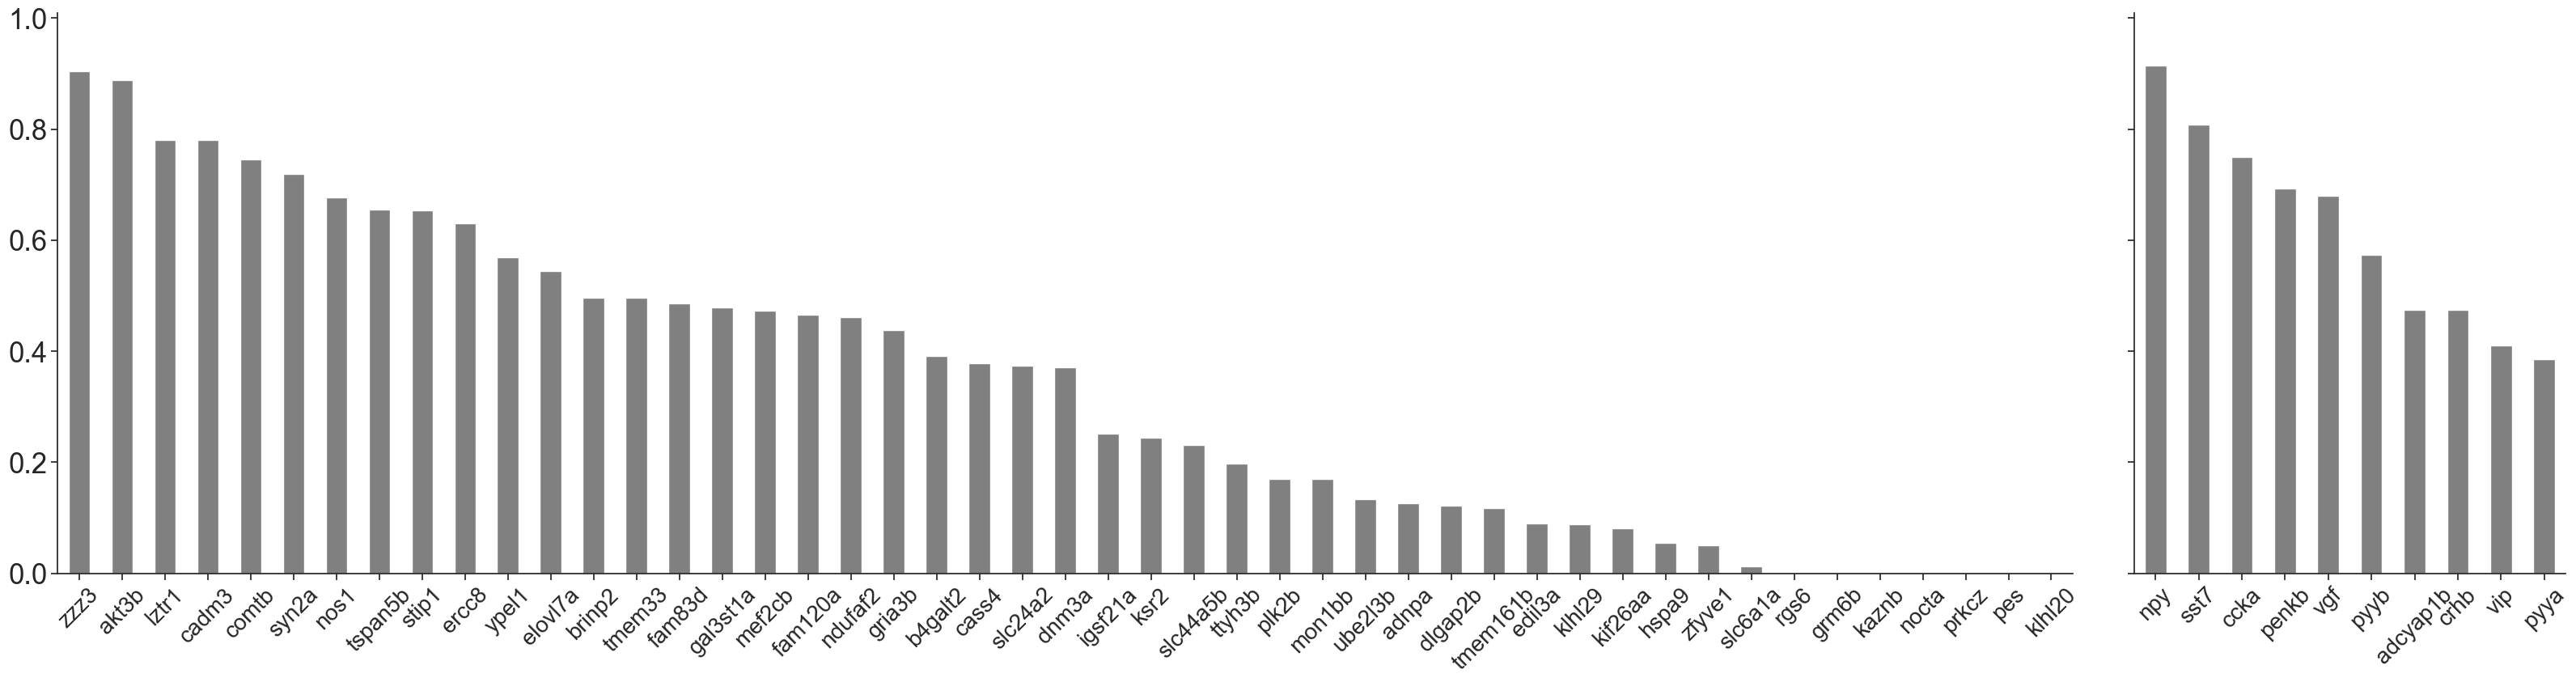

In [81]:
f,ax= plt.subplots(1,2, figsize=(40,9),width_ratios=(7,1.5),sharey=True)
plt.subplots_adjust(wspace=0.05)
npp_genes = ['sst7', 'npy', 'adcyap1b','penkb', 'vgf', 'pyya', 'pyyb','ccka','vip','crhb', 'crhb1', 'crhb2', 'crhb3']

custom_params = {"axes.spines.right": False, "axes.spines.top": False,
                 "xtick.labelsize":20,"ytick.labelsize":25,}
sns.set_theme(style="ticks", rc=custom_params)

df_sr.loc[~df_sr.index.isin(npp_genes+['nc', 'sr', 'crhb1', 'crhb2', 'crhb3', 'pnocb'])].sort_values(ascending=False).plot.bar(color='grey', ax=ax[0])
ax[0].set_ylim(0,1.01)
ax[0].tick_params(axis='x', rotation=45)
ax[0].set_yticks(np.arange(0,1.01,0.2))
ax[0].set_yticklabels(np.around(np.arange(0,1.01,0.2), decimals=1))
#ax[0].set_xlim(left=-0.5)


df_sr.loc[['sst7', 'adcyap1b','npy', 'penkb', 'vgf', 'pyya', 'pyyb','ccka','vip','crhb', 'crhb1', 'crhb2', 'crhb3']].iloc[:-3].sort_values(ascending=False).plot.bar(color='grey', ax=ax[1])
ax[1].tick_params(axis='x', rotation=45)
#ax[1].set_xlim(left=-0.5)

plt.show()

### <span style="color:red">Save the result for publication</span>

In [296]:
output_dir = '/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/doc/submission_2025/Supplementary_tables/'
fn='Table S15 Crispr gRNA design.xlsx'
with pd.ExcelWriter(
        output_dir+fn,
        mode="a",
        engine="openpyxl",
        if_sheet_exists="replace",
    ) as writer:
    df_sr.to_excel(writer, sheet_name="survival rate", index=True)

#### Functions ####

In [41]:
RawDataReformat('ArenaWiseStatistics-'+date+'.xlsx',wdir)

KeyError: 'Independent Variable'

In [37]:
def RawDataReformat(datafile,inputdir):
    Type=datafile.split('W')[0]
    Week=datafile.split('-')[1].split('.')[0]
    df = pd.read_excel(inputdir+datafile)

    
    del df['Unnamed: 0']
    if df['Independent Variable'][1] == 'Notes':
        del df['Independent Variable']
    df.insert(0, 'Week', Week)
    if Type=='Arena':
        df.rename(columns={'Unnamed: 1':'ETrial', 'Unnamed: 2':'Arena'}, inplace=True)
    else:
        df.rename(columns={'Unnamed: 1':'ETrial', 'Unnamed: 2':'Arena', 'Unnamed: 3':Type}, inplace=True)
    

    #grab the columns with plate position information and rename them
    #this is the same for all the three raw datafile
    columnlabel = ['Pcolumn', 'Plate', 'Prow', 'Well']
    for column in df.columns:
        if df[column][1] in columnlabel:
            df.rename(columns={column:df[column][1]}, inplace=True)
    #set up a list of column labels of parameters based on the order of the output of EthoVision
    #this is the same for all the three raw datafile
    Parameterlist = ['Total_distance_moved', 'Mean_velocity', 'D_zone_entry',
           'D_zone_cumulative_duration', 'D_zone_latency_to_first_entry',
           'L_zone_entry', 'L_zone_cumulative_duration',
           'L_zone_latency_to_first_entry', 'Inner_zone_entry',
           'Inner_zone_cumulative_duration',
           'Inner_zone_latency_to_first_entry', 'Outer_zone_entry',
           'Outer_zone_cumulative_duration',
           'Outer_zone_latency_to_first_entry']
    newcolumns = list(df.columns[:list(df.columns).index('Distance moved')])+Parameterlist
    if len(list(df.columns)) == len(newcolumns):
        df.columns=newcolumns
    else:
        print('new columns do not match the format of the raw data file %s'%(datafile))
    df = df[3:]#delete the first two rows
    #insert a column of fish_ID
    df.insert(0, 'Fish_ID', df['Week']+'-'+df['Plate']+'-'+df['Pcolumn']+df['Prow'])
    #use Fish_ID as the index of df_arena
    df = df.set_index('Fish_ID')
    
    #exclude dead fish from this week
    #df_dead_fish=pd.read_excel('../RawData/Dead_fish.xlsx')
    #df_dead_fish=df_dead_fish.loc[df_dead_fish['Fish_ID'].str.split('-').str[0]==Week]
    
    #df.drop(df_dead_fish['Fish_ID'], inplace=True)
    
    #print('exclude %i dead fish for week %s'%(df_dead_fish.shape[0], Week))
    #Convert Etrial from 1 to 192 into Trial from 1 to 4
    df['ETrial']=df['ETrial'].str.split(' ').str[-1].astype('int32')
    #apply the following function to normal weeks
    def Etrial_to_Trial1(Etrial):
            resi = Etrial%4
            if resi == 0:
                Trial = 4
            else:
                Trial = resi
            return Trial
    #apply the following function to dark_forced weeks including
    #[20200728, 20200811, 20200818, 20200825, 20200901]
    def Etrial_to_Trial2(Etrial):
        return round(Etrial/48)
        
        
    if int(Week)>20200721 and int(Week)!=20210203:
        df.insert(0,'Trial', df['ETrial'].apply(lambda x: math.ceil(x/48)))
    else:
        df.insert(0,'Trial', df['ETrial'].apply(lambda x: Etrial_to_Trial1(x)))
  
    #check row number for each of the three excel files
    if Type =='Arena':
        #if df.shape[0] ==768-df_dead_fish.shape[0]*4:
        if df.shape[0]:
            print('Row number of ArenaWiseStatistics for week %s is correct'%(Week))
        else:
            print('Row number of ArenaWiseStatistics for week of %s is incorrect'%(Week))
    if Type =='Bin':
        #delete the row with the Time Bin of '0:08:00-0:08:30' in BinWiseStatistics
        df = df.loc[df['Bin']!='0:08:00-0:08:30']

    if Type =='Zone':
        #if df.shape[0] ==1536-df_dead_fish.shape[0]*4*2:
        if df.shape[0] ==1536:
            print('Row number of ZoneWiseStatistics for week %s is correct'%(Week))
        else:
            print('Row number of ZoneWiseStatistics for week %s is incorrect'%(Week))
            
    #delete 12G and 12H from each plate as they were empty
    
    if Week not in ['20191217', '20191209']: 
        df.drop([Week+'-Plate1-12G'], inplace=True)
        df.drop([Week+'-Plate1-12H'], inplace=True)
        df.drop([Week+'-Plate2-12G'], inplace=True)
        df.drop([Week+'-Plate2-12H'], inplace=True)
    
    return df